# Demonstration: Generalized VB Driver with Orbital Classification

This notebook demonstrates the new generalization step in the VeloxChem VB driver. The driver now uses the OrbitalAnalyzer to automatically classify orbitals (sigma, pi, etc.) for any molecule and basis, laying the foundation for robust, flexible VB calculations.

## Example: Sigma/Pi Classification for a Small Molecule

In [1]:
import veloxchem as vlx
import veloxchem.vbdriver as vbdriver_module
import veloxchem.orbitalanalyzerdriver as analyzer_module
from veloxchem.vbdriver import VbDriver, VbComputeOptions

print("VB driver module:", vbdriver_module.__file__)
print("OrbitalAnalyzer module:", analyzer_module.__file__)

# Define a small closed-shell molecule for the shared analyzer path.
mol = vlx.Molecule.read_xyz_string('''3
water
O 0.000 0.000 0.000
H 0.758 0.000 0.584
H -0.758 0.000 0.584
''')
basis = vlx.MolecularBasis.read(mol, 'sto-3g')

vb = VbDriver()
results = vb.compute(mol, basis)

# Show all analyzer-derived orbitals exposed through VB diagnostics.
print('Orbital analysis source:', results['diagnostics'].get('orbital_analysis_source'))
print('Orbital labels:', results['diagnostics'].get('orbital_labels', []))
print('Orbital types:', results['diagnostics'].get('orbital_types', []))
print('Diagnostics:', results['diagnostics']['message'])

VB driver module: /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/vbdriver.py
OrbitalAnalyzer module: /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/orbitalanalyzerdriver.py
                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
               

## Shared NBO/VB analyzer consistency check

This checks that `VbDriver` and `NboDriver` see the same candidate labels from the shared `OrbitalAnalyzer` payload. Run this after compiling/installing the local source into the `vlxsrc` environment.

In [2]:
from veloxchem.orbitalanalyzerdriver import OrbitalAnalyzer, OrbitalAnalyzerOptions

scf = vlx.ScfRestrictedDriver()
scf.compute(mol, basis)
analysis = OrbitalAnalyzer(
    mol,
    basis,
    mol_orbs=scf.mol_orbs,
    options=OrbitalAnalyzerOptions(include_mo_analysis=False),
).run()

analyzer_labels = [
    f"{c['type']}_{c.get('subtype', '')}_{c['index']}".replace("__", "_")
    for c in analysis.orbital_candidates
]
vb_labels = results["diagnostics"].get("orbital_labels", [])

nbo = vlx.NboDriver()
nbo.verbose = False
nbo_results = nbo.compute(mol, basis, scf.mol_orbs)
nbo_analysis_labels = [
    f"{c['type']}_{c.get('subtype', '')}_{c['index']}".replace("__", "_")
    for c in nbo_results["orbital_analysis"].orbital_candidates
]

print("Analyzer labels:", analyzer_labels)
print("VB labels:      ", vb_labels)
print("NBO labels:     ", nbo_analysis_labels)
assert vb_labels == analyzer_labels
assert nbo_analysis_labels == analyzer_labels

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

# Test of VBDriver: Minimal H2 VB-CI

This notebook demonstrates and tests the minimal valence bond configuration interaction (VB-CI) implementation for H$_2$ in VeloxChem.

In [3]:
# Import required libraries
import numpy as np
from veloxchem.vbdriver import VbDriver, VbComputeOptions, VbOrbital, VbStructure

In [4]:
import sys
import os

print("Python executable:", sys.executable)
print("sys.path:")
for p in sys.path:
    print("  ", p)
print("Conda prefix:", os.environ.get("CONDA_PREFIX", "not set"))

try:
    import veloxchem.veloxchemlib as veloxchemlib
    print("veloxchemlib location:", veloxchemlib.__file__)
except ImportError:
    print("veloxchemlib not found in this environment!")

Python executable: /home/mathieu-linares/miniconda3/envs/vlxsrc/bin/python
sys.path:
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python313.zip
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/lib-dynload
   
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages
Conda prefix: /home/mathieu-linares/miniconda3/envs/vlxsrc
veloxchemlib location: /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/veloxchemlib.cpython-313-x86_64-linux-gnu.so


In [5]:
# Initialize VeloxChem Molecule Object for H2
import veloxchem as vlx

# Define H2 geometry (in Angstrom)
h2_xyz = """
2
H2 molecule
H 0.0 0.0 0.0
H 0.74 0.0 0.0
"""

molecule = vlx.Molecule.read_xyz_string(h2_xyz)
# Use a larger basis set for meaningful VB structure algebra
basis = vlx.MolecularBasis.read(molecule, '6-31g')


## Phase 4 preview: one active H2 bond from `OrbitalAnalyzer`

This cell exercises the new active-space bridge. No explicit VB structures or active orbitals are supplied: `VbDriver` asks `OrbitalAnalyzer` for the H-H bond candidate, builds one active bond, generates covalent/ionic structures, and solves the resulting two-orbital VB-CI problem.

In [6]:
# Build the first general VB active space directly from analyzer candidates.
active_options = VbComputeOptions(mode='vbci', optimize_orbitals=False)
vb = VbDriver()
active_results = vb.compute(molecule, basis, options=active_options)
active_space = active_results['active_space']

print('Active-space model:', active_results['diagnostics']['active_space_model'])
print('Active bond:', active_space.active_bond)
print('Active candidate:', active_space.active_candidate_label)
print('Active orbitals:', active_results['diagnostics']['active_orbital_labels'])
print('Generated structures:', active_results['diagnostics']['generated_structure_labels'])
print('Energy:', active_results['energy'])
print('Weights:', active_results['weights'])

assert active_space.active_bond == (0, 1)
assert active_results['diagnostics']['generated_structure_labels'] == [
    'covalent',
    'ionic_A_minus_B_plus',
    'ionic_A_plus_B_minus',
]

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [7]:
# Set Up VBDriver Calculation: define three VB structures (orbitals will be constructed by the driver)
# Covalent: one electron on each atom
covalent = VbStructure(label='covalent', occupation=((1, 1),), spin='singlet', charge_pattern={0: 0, 1: 0})
# Ionic 1: both electrons on atom 1
ionic1 = VbStructure(label='ionic1', occupation=((2, 0),), spin='singlet', charge_pattern={0: -1, 1: +1})
# Ionic 2: both electrons on atom 2
ionic2 = VbStructure(label='ionic2', occupation=((0, 2),), spin='singlet', charge_pattern={0: +1, 1: -1})

structures = [covalent, ionic1, ionic2]
options = VbComputeOptions(mode='vbci', optimize_orbitals=False)
# Do not define orbitals here; let the driver construct them


In [8]:
# Run VBDriver Calculation
vb = VbDriver()
results = vb.compute(molecule, basis, structures, options=options)


In [9]:
# Display Calculation Results
from pprint import pprint
print("VBDriver minimal H2 VB-CI result:")
pprint(results)

VBDriver minimal H2 VB-CI result:
{'Hamiltonian': array([[-4.65979328, -3.19283875, -3.19283875],
       [-3.19283875, -2.27413803, -1.92875987],
       [-3.19283875, -1.92875987, -2.27413803]]),
 'diagnostics': {'available_weight_schemes': ['Chirgwin-Coulson', 'Lowdin'],
                 'best_localized_template_energy': -1.1353473073159919,
                 'best_localized_template_index': 0,
                 'best_localized_template_label': 'covalent',
                 'localized_template_energies': [-1.1353473073159919,
                                                 -0.8269796559039789,
                                                 -0.8269796559039789],
                 'localized_template_energy_model': 'single-basis-vector '
                                                    'Rayleigh quotient '
                                                    'H_ii/S_ii in the reported '
                                                    'VB basis',
                 'localized_template

In [10]:
# Independent manual check of the spin-adapted two-orbital VB matrices
import numpy as np
import veloxchem as vlx
from veloxchem import FockDriver

# AO integrals from the supported VeloxChem Python API
T_ao = vlx.KineticEnergyDriver().compute(molecule, basis).to_numpy()
V_ao = vlx.NuclearPotentialDriver().compute(molecule, basis).to_numpy()
H_ao = T_ao - V_ao
S_ao = vlx.OverlapDriver().compute(molecule, basis).to_numpy()
eri_ao = FockDriver().compute_eri(molecule, basis, eri_thresh=1.0e-12)
e_nuc = molecule.effective_nuclear_repulsion_energy(basis)

assert np.max(np.abs(eri_ao)) > 1.0e-14, "AO ERIs are zero; rebuild/check the ERI path before interpreting VB energies."

# Use the same atom-centered orbitals and structures as VBDriver.
C = np.column_stack([results["orbitals"][0], results["orbitals"][1]])
S, H = vb._build_two_orbital_singlet_matrices(structures, C, H_ao, S_ao, eri_ao, e_nuc)
E_fci, C_fci, W_fci, kept, W_lowdin = vb._solve_generalized_vb(H, S, return_lowdin=True)

print("Manual spin-adapted VB energy:", E_fci)
print("Manual spin-adapted coefficients:", C_fci)
print("Manual Chirgwin-Coulson weights:", W_fci)
print("Manual Lowdin weights:", W_lowdin)
print("Retained overlap rank:", len(kept))
print("Overlap eigenvalues:", np.linalg.eigvalsh(S))
print("Hamiltonian matrix:\n", H)

assert np.allclose(E_fci, results["energy"])
assert np.allclose(W_fci, results["weights"])
assert np.allclose(W_lowdin, results["lowdin_weights"])
assert len(kept) == 3

Manual spin-adapted VB energy: -1.141434374256794
Manual spin-adapted coefficients: [0.40572828 0.06532426 0.06532426]
Manual Chirgwin-Coulson weights: [0.82030059 0.0898497  0.0898497 ]
Manual Lowdin weights: [0.60891137 0.19554432 0.19554432]
Retained overlap rank: 3
Overlap eigenvalues: [0.24455369 1.39557568 7.96402397]
Hamiltonian matrix:
 [[-4.65979328 -3.19283875 -3.19283875]
 [-3.19283875 -2.27413803 -1.92875987]
 [-3.19283875 -1.92875987 -2.27413803]]


Comparison of VBDriver and manual spin-adapted matrix check:
VBDriver energy: -1.14143437
Manual energy:   -1.14143437

VBDriver structure coefficients: [0.40572828 0.06532426 0.06532426]
VBDriver Chirgwin-Coulson weights: [0.82030059 0.0898497  0.0898497 ]
VBDriver Lowdin weights: [0.60891137 0.19554432 0.19554432]
Manual coefficients: [0.40572828 0.06532426 0.06532426]


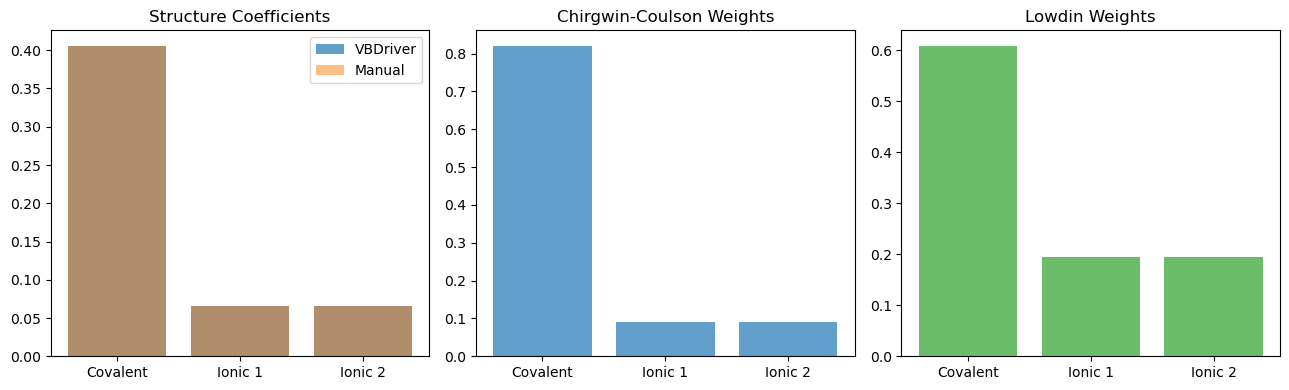

In [11]:
# Automated comparison of VBDriver and the manual matrix check
import numpy as np
import matplotlib.pyplot as plt

# Extract energies
vb_energy = results["energy"]
manual_energy = E_fci

# Extract structure coefficients and weights
vb_coeffs = results["structure_coefficients"]
vb_weights = results["weights"]
vb_lowdin_weights = results["lowdin_weights"]
manual_coeffs = C_fci

# Print summary
print("Comparison of VBDriver and manual spin-adapted matrix check:")
print(f"VBDriver energy: {vb_energy:.8f}")
print(f"Manual energy:   {manual_energy:.8f}")
print("\nVBDriver structure coefficients:", vb_coeffs)
print("VBDriver Chirgwin-Coulson weights:", vb_weights)
print("VBDriver Lowdin weights:", vb_lowdin_weights)
print("Manual coefficients:", manual_coeffs)

# Bar plot of coefficients/weights
labels = ["Covalent", "Ionic 1", "Ionic 2"]
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].bar(labels, vb_coeffs, color="tab:blue", alpha=0.7, label="VBDriver")
axs[0].bar(labels, manual_coeffs, color="tab:orange", alpha=0.5, label="Manual")
axs[0].set_title("Structure Coefficients")
axs[0].legend()
axs[1].bar(labels, vb_weights, color="tab:blue", alpha=0.7)
axs[1].set_title("Chirgwin-Coulson Weights")
axs[2].bar(labels, vb_lowdin_weights, color="tab:green", alpha=0.7)
axs[2].set_title("Lowdin Weights")
plt.tight_layout()
plt.show()

In [12]:
# Diagnostic only: H2 VB-SCF one-angle orbital optimization via driver
# The fixed-orbital VB-CI cells above are the validated baseline. This cell is
# retained to inspect the prototype orbital optimizer before using it in scans.
options_vbscf = VbComputeOptions(mode='vbscf', optimize_orbitals=True)
vb = VbDriver()
results_vbscf = vb.compute(molecule, basis, structures, options=options_vbscf)

from pprint import pprint
print("H2 VB-SCF diagnostic result:")
pprint(results_vbscf)
if 'diagnostics' in results_vbscf:
    print("\nDiagnostics:")
    for k, v in results_vbscf['diagnostics'].items():
        print(f"{k}: {v}")

H2 VB-SCF diagnostic result:
{'Hamiltonian': array([[ 0.19032253, -0.38286474, -0.36819679],
       [-0.38286474,  0.14781109,  0.29501138],
       [-0.36819679,  0.29501138,  0.10251098]]),
 'diagnostics': {'available_weight_schemes': ['Chirgwin-Coulson', 'Lowdin'],
                 'best_localized_template_energy': 0.1025109801929724,
                 'best_localized_template_index': 2,
                 'best_localized_template_label': 'ionic2',
                 'common_orbitals': True,
                 'localized_template_energies': [0.14591618250905353,
                                                 0.14781108617341449,
                                                 0.1025109801929724],
                 'localized_template_energy_model': 'single-basis-vector '
                                                    'Rayleigh quotient '
                                                    'H_ii/S_ii in the reported '
                                                    'VB basis',
   

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

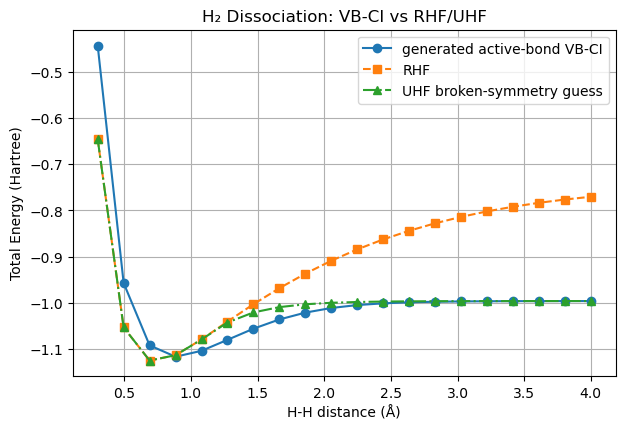

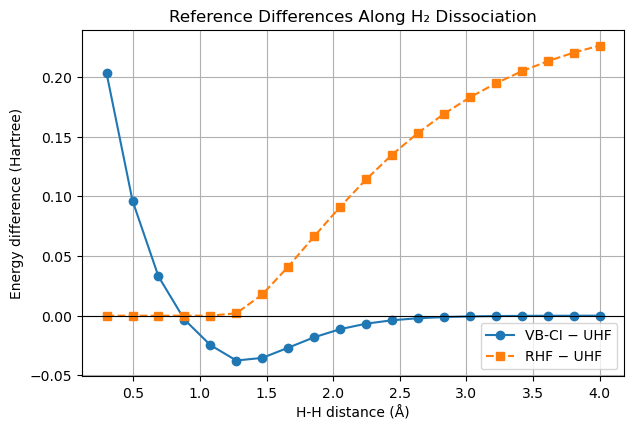

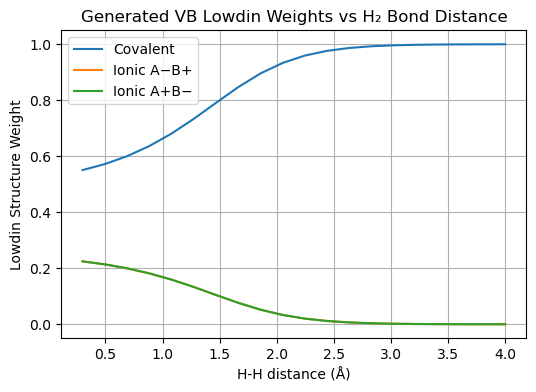

Active candidates along scan: ['H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma', 'H2_atom_centered_sigma']
Chirgwin-Coulson weights at shortest distance: [ 1.46627182 -0.23313591 -0.23313591]
Lowdin weights at shortest distance: [0.55068165 0.22465918 0.22465918]
Energy comparison at largest distance:
  VB-CI: -0.996498136612
  RHF:   -0.770202601600
  UHF:   -0.996485078491
Diagnostics at largest distance:
message: Two-electron VB-CI result from spin-adapted singlet structures.
overlap_condition: 1.0187181568869441
overlap_eigenvalues: [0.9907489972

In [13]:
# H2 dissociation curve with generated one-active-bond VB-CI
import numpy as np
import matplotlib.pyplot as plt

# Define bond distances (in Angstrom)
distances = np.linspace(0.3, 4.0, 20)

# No explicit structures are supplied here. The driver builds the active H-H
# bond and covalent/ionic structures from OrbitalAnalyzer candidates at each R.
# Keep this first dissociation scan as VB-CI over atom-centered active orbitals;
# orbital optimization is a separate diagnostic cell until its constraints are improved.
options_scan = VbComputeOptions(mode='vbci', optimize_orbitals=False)
vb = VbDriver()

def run_hf_reference(molecule, basis, unrestricted=False):
    """Run a compact HF reference calculation and return the total SCF energy."""
    scf_drv = vlx.ScfUnrestrictedDriver() if unrestricted else vlx.ScfRestrictedDriver()
    scf_drv.ostream.mute()
    scf_drv.xcfun = 'hf'
    if unrestricted:
        # Broken-symmetry singlet guess: alpha density starts on atom 1 and beta on atom 2.
        # At short distances UHF may collapse back to RHF; at long distances it should
        # recover the correct separated-atom limit much better than RHF.
        scf_drv.guess_unpaired_electrons = '1(1),2(-1)'
    scf_drv.compute(molecule, basis)
    return scf_drv.get_scf_energy()

energies = []
rhf_energies = []
uhf_energies = []
cc_weights = []
lowdin_weights = []
diagnostics = []
active_labels = []

for R in distances:
    h2_xyz = f"""2
H2 molecule
H 0.0 0.0 0.0
H {R:.8f} 0.0 0.0
"""
    molecule_R = vlx.Molecule.read_xyz_string(h2_xyz)
    basis_R = vlx.MolecularBasis.read(molecule_R, '6-31g')

    results_R = vb.compute(molecule_R, basis_R, options=options_scan)
    energies.append(results_R['energy'])
    cc_weights.append(results_R['weights'])
    lowdin_weights.append(results_R['lowdin_weights'])
    diagnostics.append(results_R.get('diagnostics', {}))
    active_labels.append(results_R['active_space'].active_candidate_label)

    rhf_energies.append(run_hf_reference(molecule_R, basis_R, unrestricted=False))
    uhf_energies.append(run_hf_reference(molecule_R, basis_R, unrestricted=True))

energies = np.array(energies)
rhf_energies = np.array(rhf_energies)
uhf_energies = np.array(uhf_energies)
cc_weights = np.array(cc_weights)
lowdin_weights = np.array(lowdin_weights)
weights = cc_weights  # backward-compatible name for the compact summary cell

assert np.all(np.isfinite(energies))
assert np.all(np.isfinite(rhf_energies))
assert np.all(np.isfinite(uhf_energies))
assert all(d.get('retained_overlap_rank') == 3 for d in diagnostics)
assert np.allclose(np.sum(cc_weights, axis=1), 1.0)
assert np.allclose(np.sum(lowdin_weights, axis=1), 1.0)

# Plot total energy vs bond distance, including RHF/UHF references.
plt.figure(figsize=(7, 4.5))
plt.plot(distances, energies, marker='o', label='generated active-bond VB-CI')
plt.plot(distances, rhf_energies, marker='s', linestyle='--', label='RHF')
plt.plot(distances, uhf_energies, marker='^', linestyle='-.', label='UHF broken-symmetry guess')
plt.xlabel('H-H distance (Å)')
plt.ylabel('Total Energy (Hartree)')
plt.title('H₂ Dissociation: VB-CI vs RHF/UHF')
plt.grid(True)
plt.legend()
plt.show()

# Plot relative errors against UHF to make the dissociation-limit behavior visible.
plt.figure(figsize=(7, 4.5))
plt.plot(distances, energies - uhf_energies, marker='o', label='VB-CI − UHF')
plt.plot(distances, rhf_energies - uhf_energies, marker='s', linestyle='--', label='RHF − UHF')
plt.axhline(0.0, color='black', linewidth=0.8)
plt.xlabel('H-H distance (Å)')
plt.ylabel('Energy difference (Hartree)')
plt.title('Reference Differences Along H₂ Dissociation')
plt.grid(True)
plt.legend()
plt.show()

# Plot Lowdin weights for bounded visual interpretation.
plt.figure(figsize=(6, 4))
plt.plot(distances, lowdin_weights[:, 0], label='Covalent')
if lowdin_weights.shape[1] > 1:
    plt.plot(distances, lowdin_weights[:, 1], label='Ionic A−B+')
if lowdin_weights.shape[1] > 2:
    plt.plot(distances, lowdin_weights[:, 2], label='Ionic A+B−')
plt.xlabel('H-H distance (Å)')
plt.ylabel('Lowdin Structure Weight')
plt.title('Generated VB Lowdin Weights vs H₂ Bond Distance')
plt.grid(True)
plt.legend()
plt.show()

print('Active candidates along scan:', active_labels)
print('Chirgwin-Coulson weights at shortest distance:', cc_weights[0])
print('Lowdin weights at shortest distance:', lowdin_weights[0])
print('Energy comparison at largest distance:')
print(f"  VB-CI: {energies[-1]: .12f}")
print(f"  RHF:   {rhf_energies[-1]: .12f}")
print(f"  UHF:   {uhf_energies[-1]: .12f}")
print('Diagnostics at largest distance:')
for k, v in diagnostics[-1].items():
    print(f"{k}: {v}")

In [14]:
# Compact analysis summary for VB notebook results
import numpy as np

print('--- Active-space H2 one-geometry summary ---')
if 'active_results' in globals():
    print('energy:', active_results.get('energy'))
    print('Chirgwin-Coulson weights:', np.asarray(active_results.get('weights')))
    print('Lowdin weights:', np.asarray(active_results.get('lowdin_weights')))
    print('coefficients:', np.asarray(active_results.get('structure_coefficients')))
    print('overlap condition:', active_results.get('diagnostics', {}).get('overlap_condition'))
    print('overlap eigenvalues:', active_results.get('diagnostics', {}).get('overlap_eigenvalues'))
    print('active candidate:', active_results.get('diagnostics', {}).get('active_candidate_label'))
    print('structures:', active_results.get('diagnostics', {}).get('generated_structure_labels'))

print('\n--- Explicit H2 VB-CI summary ---')
if 'results' in globals():
    print('energy:', results.get('energy'))
    print('Chirgwin-Coulson weights:', np.asarray(results.get('weights')))
    print('Lowdin weights:', np.asarray(results.get('lowdin_weights')))
    print('coefficients:', np.asarray(results.get('structure_coefficients')))
    print('overlap condition:', results.get('diagnostics', {}).get('overlap_condition'))

print('\n--- Manual spin-adapted matrix summary ---')
if 'E_fci' in globals():
    print('E_manual:', E_fci)
    print('C_manual:', C_fci)
    if 'W_fci' in globals():
        print('W_manual_CC:', W_fci)
    if 'W_lowdin' in globals():
        print('W_manual_Lowdin:', W_lowdin)

print('\n--- VB-SCF one-geometry diagnostic summary ---')
if 'results_vbscf' in globals():
    print('energy:', results_vbscf.get('energy'))
    print('Chirgwin-Coulson weights:', np.asarray(results_vbscf.get('weights')))
    print('Lowdin weights:', np.asarray(results_vbscf.get('lowdin_weights')))
    print('coefficients:', np.asarray(results_vbscf.get('structure_coefficients')))
    print('theta:', results_vbscf.get('diagnostics', {}).get('theta_opt'))
    print('overlap condition:', results_vbscf.get('diagnostics', {}).get('overlap_condition'))

print('\n--- VB-CI/RHF/UHF dissociation summary ---')
if 'distances' in globals() and 'energies' in globals() and 'weights' in globals():
    have_hf_refs = 'rhf_energies' in globals() and 'uhf_energies' in globals()
    if have_hf_refs:
        print('distance VB-CI RHF UHF VB-UHF RHF-UHF CC_cov CC_ion1 CC_ion2 Lowdin_cov Lowdin_ion1 Lowdin_ion2')
    else:
        print('distance VB-CI CC_cov CC_ion1 CC_ion2 Lowdin_cov Lowdin_ion1 Lowdin_ion2')
    lowdin_table = lowdin_weights if 'lowdin_weights' in globals() else weights
    for idx in range(len(distances)):
        cc_row = np.asarray(weights[idx])
        lowdin_row = np.asarray(lowdin_table[idx])
        cc_padded = np.pad(cc_row, (0, max(0, 3 - cc_row.size)), constant_values=np.nan)
        lowdin_padded = np.pad(lowdin_row, (0, max(0, 3 - lowdin_row.size)), constant_values=np.nan)
        if have_hf_refs:
            print(
                f'{distances[idx]:.3f} {energies[idx]: .8e} {rhf_energies[idx]: .8e} {uhf_energies[idx]: .8e} '
                f'{energies[idx] - uhf_energies[idx]: .3e} {rhf_energies[idx] - uhf_energies[idx]: .3e} '
                f'{cc_padded[0]: .6f} {cc_padded[1]: .6f} {cc_padded[2]: .6f} '
                f'{lowdin_padded[0]: .6f} {lowdin_padded[1]: .6f} {lowdin_padded[2]: .6f}'
            )
        else:
            print(
                f'{distances[idx]:.3f} {energies[idx]: .8e} '
                f'{cc_padded[0]: .6f} {cc_padded[1]: .6f} {cc_padded[2]: .6f} '
                f'{lowdin_padded[0]: .6f} {lowdin_padded[1]: .6f} {lowdin_padded[2]: .6f}'
            )
    print('finite VB-CI energies:', bool(np.all(np.isfinite(energies))))
    if have_hf_refs:
        print('finite RHF energies:', bool(np.all(np.isfinite(rhf_energies))))
        print('finite UHF energies:', bool(np.all(np.isfinite(uhf_energies))))
    print('VB-CI energy min/max:', float(np.nanmin(energies)), float(np.nanmax(energies)))
    if have_hf_refs:
        print('RHF energy min/max:', float(np.nanmin(rhf_energies)), float(np.nanmax(rhf_energies)))
        print('UHF energy min/max:', float(np.nanmin(uhf_energies)), float(np.nanmax(uhf_energies)))
    if 'diagnostics' in globals() and diagnostics:
        print('last diagnostics:', diagnostics[-1])

--- Active-space H2 one-geometry summary ---
energy: -1.1053297868435705
Chirgwin-Coulson weights: [0.89024766 0.05487617 0.05487617]
Lowdin weights: [0.6087942 0.1956029 0.1956029]
coefficients: [-0.7122147  -0.06406214 -0.06406214]
overlap condition: 49.44680728210356
overlap eigenvalues: [0.062005417617485126, 0.43601232350218666, 3.0659699353781416]
active candidate: H2_atom_centered_sigma
structures: ['covalent', 'ionic_A_minus_B_plus', 'ionic_A_plus_B_minus']

--- Explicit H2 VB-CI summary ---
energy: -1.141434374256794
Chirgwin-Coulson weights: [0.82030059 0.0898497  0.0898497 ]
Lowdin weights: [0.60891137 0.19554432 0.19554432]
coefficients: [0.40572828 0.06532426 0.06532426]
overlap condition: 32.565543598849835

--- Manual spin-adapted matrix summary ---
E_manual: -1.141434374256794
C_manual: [0.40572828 0.06532426 0.06532426]
W_manual_CC: [0.82030059 0.0898497  0.0898497 ]
W_manual_Lowdin: [0.60891137 0.19554432 0.19554432]

--- VB-SCF one-geometry diagnostic summary ---
ene

## Ethylene sigma/pi separation preview

This cell is the next generalization checkpoint. It does not solve an ethylene VB wavefunction yet. Instead, it verifies that `VbDriver` exposes the `OrbitalAnalyzer` bond manifold in a VB-facing form: C=C sigma candidates, C=C pi candidates, and suggested active candidates. After recompiling, the pi candidate label reported here is the intended entry point for the next one-active-π-bond VB model.

In [15]:
# Ethylene C=C sigma/pi separation through VbDriver diagnostics
import veloxchem as vlx
from veloxchem.vbdriver import VbDriver, VbComputeOptions

ethylene_xyz = """6
ethylene
C -0.6695  0.0000  0.0000
C  0.6695  0.0000  0.0000
H -1.2321  0.9289  0.0000
H -1.2321 -0.9289  0.0000
H  1.2321  0.9289  0.0000
H  1.2321 -0.9289  0.0000
"""

ethylene = vlx.Molecule.read_xyz_string(ethylene_xyz)
ethylene_basis = vlx.MolecularBasis.read(ethylene, 'sto-3g')

# Keep automatic active-space generation off here: the purpose is to inspect
# analyzer-derived bond manifolds before turning the C=C pi candidate into a
# production VB active space.
vb = VbDriver()
ethylene_results = vb.compute(
    ethylene,
    ethylene_basis,
    options=VbComputeOptions(mode='vbci', optimize_orbitals=False, use_active_space=False),
)
ethylene_diag = ethylene_results['diagnostics']
partitions = ethylene_diag['candidate_partitions']

sigma_bonds = partitions['sigma_bonds']
pi_bonds = partitions['pi_bonds']
suggested = ethylene_diag['suggested_active_candidates']

print('Sigma bond candidates:')
for record in sigma_bonds:
    print(record)

print('\nPi bond candidates:')
for record in pi_bonds:
    print(record)

print('\nSuggested active candidates:')
for record in suggested:
    print(record)

# C atoms are atoms 0 and 1 in this geometry. The next VB target is the C=C pi
# candidate, while the C=C sigma bond and C-H sigma bonds remain inactive/frozen.
cc_pi = [record for record in pi_bonds if tuple(record['atoms']) == (0, 1)]
cc_sigma = [record for record in sigma_bonds if tuple(record['atoms']) == (0, 1)]

assert cc_pi, 'Expected a C=C pi bond candidate for ethylene.'
assert cc_sigma, 'Expected a C=C sigma bond candidate for ethylene.'

pi_label = cc_pi[0]['label']
sigma_label = cc_sigma[0]['label']
print('\nEthylene C=C sigma label:', sigma_label)
print('Ethylene C=C pi label:', pi_label)
print('Use this pi label for the next one-active-pi-bond VB prototype.')

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Ethylene one-active-π VB-CI with frozen HF sigma framework

This cell activates the analyzer-selected C=C π candidate and leaves the sigma framework at the RHF reference level. The active VB structures are the π covalent and ionic structures; the C=C sigma and C-H sigma candidates are reported as inactive/frozen diagnostics.

In [16]:
# Ethylene one-active-pi VB-CI. The pi_label variable is defined by the
# previous sigma/pi checkpoint cell; rerun that cell first after recompiling.
pi_options = VbComputeOptions(
    mode='vbci',
    optimize_orbitals=False,
    active_candidate_label=pi_label,
    active_candidate_subtype='pi',
    include_ionic=True,
    freeze_inactive_orbitals=True,
)
pi_vb_results = vb.compute(ethylene, ethylene_basis, options=pi_options)
pi_vb_diag = pi_vb_results['diagnostics']

print('Active-space model:', pi_vb_diag['active_space_model'])
print('Active candidate:', pi_vb_diag['active_candidate_label'], pi_vb_diag['active_candidate_subtype'])
print('Active bond:', pi_vb_diag['active_bond'])
print('Active orbitals:', pi_vb_diag['active_orbital_labels'])
print('Structures:', pi_vb_diag['generated_structure_labels'])
print('Inactive sigma framework:', pi_vb_diag['inactive_sigma_candidate_labels'])
print('Frozen HF embedding:', pi_vb_diag.get('frozen_hf_embedding', False))
print('Frozen electrons:', pi_vb_diag.get('frozen_electron_count'))
print('Active reference electrons:', pi_vb_diag.get('active_reference_electron_count'))
print('Frozen constant energy:', pi_vb_diag.get('frozen_constant_energy'))
print('VB-CI energy:', pi_vb_results['energy'])
print('Overlap eigenvalues:', pi_vb_diag['overlap_eigenvalues'])

for label, coeff, cc_weight, lowdin_weight in zip(
    pi_vb_diag['generated_structure_labels'],
    pi_vb_results['structure_coefficients'],
    pi_vb_results['weights'],
    pi_vb_results['lowdin_weights'],
):
    print(f'{label:22s} coeff={coeff: .8f} CC={cc_weight: .8f} Lowdin={lowdin_weight: .8f}')

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Allyl cation fixed-orbital multi-center π VB-CI

This validation cell is the first checkpoint for the general fixed-orbital π active-space engine. The allyl cation is treated as a 2e/3π singlet active space over the three carbon π centers, while the sigma/core framework is frozen at the RHF reference level. The generated structures include all covalent two-center π placements and one ionic placement on each active center.

In [17]:
# Allyl cation 2e/3pi fixed-orbital VB-CI validation.
# Carbon atoms 0, 1, and 2 define the conjugated pi active space.
allyl_cation_xyz = """8
allyl cation
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
"""

allyl_cation = vlx.Molecule.read_xyz_string(allyl_cation_xyz)
allyl_cation.set_charge(1)
allyl_cation.set_multiplicity(1)
allyl_basis = vlx.MolecularBasis.read(allyl_cation, 'sto-3g')

allyl_options = VbComputeOptions(
    mode='vbci',
    optimize_orbitals=False,
    active_pi_atoms=(0, 1, 2),
    active_electron_count=2,
    active_spin='singlet',
    include_ionic=True,
    freeze_inactive_orbitals=True,
)
allyl_vb_results = vb.compute(allyl_cation, allyl_basis, options=allyl_options)
allyl_vb_diag = allyl_vb_results['diagnostics']

print('Active-space model:', allyl_vb_diag['active_space_model'])
print('Active pi atoms:', allyl_vb_diag['active_pi_atoms'])
print('Component pi candidates:', allyl_vb_diag['component_pi_candidate_labels'])
print('Active orbitals:', allyl_vb_diag['active_orbital_labels'])
print('Structures:', allyl_vb_diag['generated_structure_labels'])
print('Frozen HF embedding:', allyl_vb_diag.get('frozen_hf_embedding', False))
print('Frozen electrons:', allyl_vb_diag.get('frozen_electron_count'))
print('Active reference electrons:', allyl_vb_diag.get('active_reference_electron_count'))
print('Frozen constant energy:', allyl_vb_diag.get('frozen_constant_energy'))
print('VB-CI energy:', allyl_vb_results['energy'])
print('Overlap eigenvalues:', allyl_vb_diag['overlap_eigenvalues'])

for label, coeff, cc_weight, lowdin_weight in zip(
    allyl_vb_diag['generated_structure_labels'],
    allyl_vb_results['structure_coefficients'],
    allyl_vb_results['weights'],
    allyl_vb_results['lowdin_weights'],
):
    print(f'{label:24s} coeff={coeff: .8f} CC={cc_weight: .8f} Lowdin={lowdin_weight: .8f}')

assert allyl_vb_diag['active_space_model'] == 'fixed-orbital-multicenter-pi'
assert allyl_vb_diag['active_pi_atoms'] == (0, 1, 2)
assert len(allyl_vb_diag['active_orbital_labels']) == 3
assert len(allyl_vb_diag['generated_structure_labels']) == 6
assert allyl_vb_diag['retained_overlap_rank'] == 6
assert np.isfinite(allyl_vb_results['energy'])
assert np.allclose(np.sum(allyl_vb_results['weights']), 1.0)
assert np.allclose(np.sum(allyl_vb_results['lowdin_weights']), 1.0)
assert np.isclose(allyl_vb_diag.get('active_reference_electron_count'), 2.0, atol=1.0e-8)
assert allyl_vb_diag.get('frozen_electron_count') > 0.0

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Fixed-orbital π validation ladder through benzene

This cell extends the multi-center π engine beyond allyl cation. It validates allyl radical, allyl anion, butadiene, and benzene using the same `active_pi_atoms` interface. The allyl cation remains the spin-adapted 2e benchmark above; larger/open-shell cases use the fixed-orbital determinant-CI fallback in the orthonormalized active π basis while retaining frozen-HF sigma/core embedding.

In [18]:
# Remaining fixed-orbital pi validation ladder: allyl radical, allyl anion,
# butadiene, and benzene. These cases exercise 3e/3pi, 4e/3pi, 4e/4pi,
# and 6e/6pi active spaces with frozen sigma/core embedding.
pi_validation_cases = [
    {
        'name': 'allyl_radical',
        'xyz': """8
allyl radical
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
""",
        'charge': 0,
        'multiplicity': 2,
        'active_pi_atoms': (0, 1, 2),
        'active_electron_count': 3,
        'active_spin': 'doublet',
        'expected_orbitals': 3,
        'expected_structures': 9,
    },
    {
        'name': 'allyl_anion',
        'xyz': """8
allyl anion
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
""",
        'charge': -1,
        'multiplicity': 1,
        'active_pi_atoms': (0, 1, 2),
        'active_electron_count': 4,
        'active_spin': 'singlet',
        'expected_orbitals': 3,
        'expected_structures': 9,
    },
    {
        'name': 'butadiene',
        'xyz': """10
butadiene
C -1.9950  0.0000  0.0000
C -0.6650  0.0000  0.0000
C  0.6650  0.0000  0.0000
C  1.9950  0.0000  0.0000
H -2.5500  0.9200  0.0000
H -2.5500 -0.9200  0.0000
H -0.6650  1.0800  0.0000
H  0.6650 -1.0800  0.0000
H  2.5500  0.9200  0.0000
H  2.5500 -0.9200  0.0000
""",
        'charge': 0,
        'multiplicity': 1,
        'active_pi_atoms': (0, 1, 2, 3),
        'active_electron_count': 4,
        'active_spin': 'singlet',
        'expected_orbitals': 4,
        'expected_structures': 36,
    },
    {
        'name': 'benzene',
        'xyz': """12
benzene
C  1.3970  0.0000  0.0000
C  0.6985  1.2099  0.0000
C -0.6985  1.2099  0.0000
C -1.3970  0.0000  0.0000
C -0.6985 -1.2099  0.0000
C  0.6985 -1.2099  0.0000
H  2.4810  0.0000  0.0000
H  1.2405  2.1487  0.0000
H -1.2405  2.1487  0.0000
H -2.4810  0.0000  0.0000
H -1.2405 -2.1487  0.0000
H  1.2405 -2.1487  0.0000
""",
        'charge': 0,
        'multiplicity': 1,
        'active_pi_atoms': (0, 1, 2, 3, 4, 5),
        'active_electron_count': 6,
        'active_spin': 'singlet',
        'expected_orbitals': 6,
        'expected_structures': 400,
    },
]

pi_ladder_results = {}
for case in pi_validation_cases:
    mol_case = vlx.Molecule.read_xyz_string(case['xyz'])
    mol_case.set_charge(case['charge'])
    mol_case.set_multiplicity(case['multiplicity'])
    basis_case = vlx.MolecularBasis.read(mol_case, 'sto-3g')
    options_case = VbComputeOptions(
        mode='vbci',
        optimize_orbitals=False,
        active_pi_atoms=case['active_pi_atoms'],
        active_electron_count=case['active_electron_count'],
        active_spin=case['active_spin'],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )
    result_case = vb.compute(mol_case, basis_case, options=options_case)
    diag_case = result_case['diagnostics']
    pi_ladder_results[case['name']] = result_case

    print(f"\n--- {case['name']} ---")
    print('Active-space model:', diag_case['active_space_model'])
    print('Active pi atoms:', diag_case['active_pi_atoms'])
    print('Active electron count:', diag_case['active_electron_count'])
    print('Active spin:', diag_case['active_spin'])
    print('n_alpha/n_beta:', diag_case.get('n_alpha'), diag_case.get('n_beta'))
    print('Active orbitals:', len(diag_case['active_orbital_labels']), diag_case['active_orbital_labels'])
    print('Structures/determinants:', len(diag_case['generated_structure_labels']), diag_case.get('determinant_count'))
    print('Frozen HF embedding:', diag_case.get('frozen_hf_embedding', False))
    print('Frozen electrons:', diag_case.get('frozen_electron_count'))
    print('Active reference electrons:', diag_case.get('active_reference_electron_count'))
    print('VB-CI energy:', result_case['energy'])
    print('Weight sum:', float(np.sum(result_case['weights'])))
    print('Largest weights:')
    top_indices = np.argsort(np.abs(result_case['weights']))[::-1][:5]
    for idx in top_indices:
        label = diag_case['generated_structure_labels'][idx]
        coeff = result_case['structure_coefficients'][idx]
        weight = result_case['weights'][idx]
        print(f'  {label:18s} coeff={coeff: .8f} weight={weight: .8f}')

    assert diag_case['active_space_model'] == 'fixed-orbital-multicenter-pi'
    assert diag_case['active_pi_atoms'] == case['active_pi_atoms']
    assert diag_case['active_electron_count'] == case['active_electron_count']
    assert diag_case['active_spin'] == case['active_spin']
    assert len(diag_case['active_orbital_labels']) == case['expected_orbitals']
    assert len(diag_case['generated_structure_labels']) == case['expected_structures']
    assert diag_case.get('determinant_count') == case['expected_structures']
    assert np.isfinite(result_case['energy'])
    assert np.allclose(np.sum(result_case['weights']), 1.0)
    assert np.allclose(np.sum(result_case['lowdin_weights']), 1.0)
    assert np.isclose(
        diag_case.get('active_reference_electron_count'),
        case['active_electron_count'],
        atol=1.0e-8,
    )
    assert diag_case.get('frozen_electron_count') > 0.0

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Unrestricted Hartree-Fock                                       
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Chemically labeled resonance / CSF projection diagnostics

This compact checkpoint summarizes the graph-generated, spin-adapted chemical resonance templates from the fixed-orbital π determinant-CI wavefunctions. Singlet determinant-CI cases now select the lowest alpha/beta exchange-symmetric root before projection, and the CSF template phases are built directly in the alpha/beta occupation-string basis. Displayed `chemical_resonance_weights` are normalized Löwdin-style template weights after graph-automorphism averaging, so symmetry-equivalent templates carry equal displayed weights. The captured-subspace weight is reported separately. Set `VERBOSE_RESONANCE_DETAILS = True` in the next cell to inspect individual templates, unsymmetrized weights, and raw projections.

In [19]:
# Compact graph-generated spin-adapted resonance/CSF projection checkpoint.
# Rerun the pi validation ladder cell first after rebuilding the local VeloxChem package.
assert 'pi_ladder_results' in globals(), 'Run the fixed-orbital pi validation ladder cell first.'

VERBOSE_RESONANCE_DETAILS = False
LOW_CAPTURE_WARNING = 1.0e-6
MIN_BUTADIENE_CAPTURE = 1.0e-3

summary_rows = []
for case in pi_validation_cases:
    name = case['name']
    result_case = pi_ladder_results[name]
    diag_case = result_case['diagnostics']
    labels = diag_case.get('chemical_resonance_labels', [])
    types = diag_case.get('chemical_resonance_types', [])
    normalized_weights = np.asarray(diag_case.get('chemical_resonance_weights', []), dtype=float)
    unsymmetrized_weights = np.asarray(
        diag_case.get('chemical_resonance_unsymmetrized_weights', normalized_weights),
        dtype=float,
    )
    projection_weights = np.asarray(diag_case.get('chemical_resonance_projection_weights', []), dtype=float)
    details = diag_case.get('chemical_resonance_details', [])
    symmetry_orbits = diag_case.get('chemical_resonance_symmetry_orbits', [])
    normalized_sum = float(np.sum(normalized_weights))
    captured_weight = float(diag_case.get('chemical_resonance_subspace_weight', np.nan))
    raw_projection_sum = float(diag_case.get('chemical_resonance_projection_weight_sum', np.nan))
    retained_rank = diag_case.get('chemical_resonance_retained_rank')
    root_index = diag_case.get('determinant_ci_root_index')
    spin_exchange_parity = diag_case.get('determinant_ci_spin_exchange_parity')

    orbit_summary = '; '.join(
        f"{orbit.get('type')}[{orbit.get('member_count')}]={orbit.get('mean_weight'):.4f}"
        for orbit in symmetry_orbits
    )
    capture_note = 'LOW' if captured_weight < LOW_CAPTURE_WARNING else 'ok'
    parity_text = 'n/a' if spin_exchange_parity is None else f'{float(spin_exchange_parity):.3f}'
    summary_rows.append(
        (
            name,
            len(labels),
            retained_rank,
            root_index,
            parity_text,
            captured_weight,
            normalized_sum,
            raw_projection_sum,
            capture_note,
            orbit_summary,
        )
    )

    assert labels, f'Expected chemical resonance templates for {name}.'
    assert len(labels) == diag_case.get('chemical_resonance_count')
    assert len(labels) == len(types) == len(normalized_weights) == len(projection_weights) == len(details)
    assert len(labels) == len(unsymmetrized_weights)
    assert np.all(np.isfinite(normalized_weights))
    assert np.all(np.isfinite(unsymmetrized_weights))
    assert np.all(np.isfinite(projection_weights))
    assert np.all(normalized_weights >= -1.0e-12)
    assert np.all(unsymmetrized_weights >= -1.0e-12)
    assert np.all(projection_weights >= -1.0e-12)
    assert np.isclose(normalized_sum, 1.0, atol=1.0e-8), (
        f'Normalized CSF weights for {name} sum to {normalized_sum:.12f}, not 1.0. '
        'Restart the notebook kernel and rerun the fixed-orbital pi validation ladder cell so '
        'pi_ladder_results is regenerated with the rebuilt VeloxChem package.'
    )
    assert captured_weight >= -1.0e-12
    assert captured_weight <= 1.0 + 1.0e-8

    if case['active_spin'] == 'singlet':
        assert spin_exchange_parity is not None
        assert float(spin_exchange_parity) > 0.5

    if name == 'allyl_radical':
        assert set(types) == {'allyl_radical'}
        assert len(labels) == 3
    elif name == 'allyl_anion':
        assert set(types) == {'allyl_anion'}
        assert len(labels) == 3
    elif name == 'butadiene':
        assert 'butadiene_kekule' in types
        assert len(labels) == 3
        assert captured_weight > MIN_BUTADIENE_CAPTURE
    elif name == 'benzene':
        assert 'benzene_kekule' in types
        assert 'benzene_dewar' in types
        assert len(labels) == 15

    if VERBOSE_RESONANCE_DETAILS:
        print(f"\n--- {name}: individual chemical resonance templates ---")
        print('Model:', diag_case.get('chemical_resonance_model'))
        print('Symmetry model:', diag_case.get('chemical_resonance_symmetry_model'))
        print('Root selection:', diag_case.get('determinant_ci_root_selection'))
        for label, kind, weight, unsym_weight, raw_weight in zip(
            labels,
            types,
            normalized_weights,
            unsymmetrized_weights,
            projection_weights,
        ):
            print(
                f'  {kind:28s} normalized={weight: .8f} '
                f'unsym={unsym_weight: .8f} raw_projection={raw_weight: .8f}  {label}'
            )

print('case             templates rank root parity captured     norm_sum raw_proj    capture  symmetry-orbit mean weights')
print('-' * 132)
for name, n_templates, rank, root_index, parity_text, captured, norm_sum, raw_sum, capture_note, orbit_summary in summary_rows:
    print(
        f'{name:16s} {n_templates:9d} {rank:4d} {root_index!s:>4s} {parity_text:>6s} '
        f'{captured: .3e} {norm_sum: .8f} {raw_sum: .3e} {capture_note:>7s}  {orbit_summary}'
    )

low_capture_cases = [name for name, _, _, _, _, captured, *_ in summary_rows if captured < LOW_CAPTURE_WARNING]
if low_capture_cases:
    print('\nLow captured-subspace warning:', ', '.join(low_capture_cases))
    print('The symmetry-averaged weights are normalized, but these compact CSF templates do not yet capture the full determinant-CI root for the flagged case(s).')

case             templates rank root parity captured     norm_sum raw_proj    capture  symmetry-orbit mean weights
------------------------------------------------------------------------------------------------------------------------------------
allyl_radical            3    3    0    n/a  8.292e-03  1.00000000  1.392e-02      ok  allyl_radical[2]=0.4673; allyl_radical[1]=0.0655
allyl_anion              3    3    0  1.000  2.525e-01  1.00000000  2.525e-01      ok  allyl_anion[2]=0.2396; allyl_anion[1]=0.5208
butadiene                3    3    1  1.000  4.530e-01  1.00000000  4.281e-01      ok  butadiene_kekule[1]=0.9414; butadiene_long_bond_pairing[1]=0.0247; butadiene_long_bond_pairing[1]=0.0339
benzene                 15   10    0  1.000  9.418e-03  1.00000000  1.293e-02      ok  benzene_dewar[6]=0.0268; benzene_dewar[3]=0.1869; benzene_dewar[3]=0.0272; benzene_dewar[1]=0.0645; benzene_kekule[2]=0.0662


## VB stabilization table: SCF, VB correlation, and resonance energy

This checkpoint is the compact branch-stabilization table for H2, allyl cation, allyl radical, allyl anion, and benzene. It starts with fixed-orbital VBCI only. VBSCF and BOVB rows should be added system-by-system only after the corresponding VBCI row is stable.

Definitions used here:

- `E_SCF`: HF reference energy for the same molecule, charge, multiplicity, and basis.
- `E_VB`: energy reported by `VbDriver`.
- `E_corr(VB) = E_VB - E_SCF`.
- `E_res = E_best_template - E_VB`, using the driver's single-template Rayleigh-quotient diagnostic in the same VB basis.

In [20]:
# Fixed-orbital VBCI stabilization table for the core branch gate.
# Rebuild/reinstall VeloxChem first so the new localized-template diagnostics are available.

def stabilization_hf_reference(molecule, basis, unrestricted=False):
    scf = vlx.ScfUnrestrictedDriver() if unrestricted else vlx.ScfRestrictedDriver()
    scf.ostream.mute()
    scf.xcfun = "hf"
    if unrestricted:
        # Helpful for small radical/stretched-bond references; harmless if ignored by the driver.
        try:
            scf.guess_unpaired_electrons = "1(1),2(-1)"
        except Exception:
            pass
    scf.compute(molecule, basis)
    return float(scf.get_scf_energy())


def stabilization_summary_row(system, method, molecule, basis, result, unrestricted_scf=False):
    diagnostics = result.get("diagnostics", {})
    e_scf = stabilization_hf_reference(molecule, basis, unrestricted=unrestricted_scf)
    e_vb = float(result["energy"])
    e_best = float(diagnostics.get("best_localized_template_energy", np.nan))
    e_res = float(diagnostics.get("resonance_energy", np.nan))
    if not np.isfinite(e_res) and np.isfinite(e_best):
        e_res = e_best - e_vb
    captured = float(diagnostics.get("chemical_resonance_subspace_weight", np.nan))
    weight_sum = float(np.sum(np.asarray(result.get("weights", []), dtype=float)))
    lowdin_sum = float(np.sum(np.asarray(result.get("lowdin_weights", []), dtype=float)))
    return {
        "system": system,
        "method": method,
        "E_SCF": e_scf,
        "E_VB": e_vb,
        "E_corr(VB)": e_vb - e_scf,
        "E_best_template": e_best,
        "E_res": e_res,
        "captured_weight": captured,
        "weight_sum": weight_sum,
        "lowdin_weight_sum": lowdin_sum,
        "best_template": diagnostics.get("best_localized_template_label"),
        "vb_method": diagnostics.get("vb_method"),
    }


def make_stabilization_molecule(case):
    molecule = vlx.Molecule.read_xyz_string(case["xyz"])
    molecule.set_charge(case["charge"])
    molecule.set_multiplicity(case["multiplicity"])
    return molecule


allyl_cation_stabilization_case = {
    "name": "allyl_cation",
    "xyz": """8
allyl cation
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
""",
    "charge": 1,
    "multiplicity": 1,
    "active_pi_atoms": (0, 1, 2),
    "active_electron_count": 2,
    "active_spin": "singlet",
}

h2_stabilization_case = {
    "name": "H2",
    "xyz": """2
H2
H 0.00000000 0.00000000 0.00000000
H 0.74000000 0.00000000 0.00000000
""",
    "charge": 0,
    "multiplicity": 1,
}

selected_pi_cases = [allyl_cation_stabilization_case]
selected_pi_cases.extend(
    case for case in pi_validation_cases
    if case["name"] in {"allyl_radical", "allyl_anion", "benzene"}
)

vb_stabilization_rows = []
vb_stabilization_results = {}

# H2 fixed-orbital VBCI row.
h2_mol = make_stabilization_molecule(h2_stabilization_case)
h2_basis = vlx.MolecularBasis.read(h2_mol, "6-31g")
h2_vbci = vb.compute(
    h2_mol,
    h2_basis,
    options=VbComputeOptions(mode="vbci", optimize_orbitals=False, freeze_inactive_orbitals=True),
)
vb_stabilization_results[("H2", "VBCI")] = h2_vbci
vb_stabilization_rows.append(
    stabilization_summary_row("H2", "VBCI", h2_mol, h2_basis, h2_vbci)
)

# Organic pi fixed-orbital VBCI rows.
for case in selected_pi_cases:
    mol_case = make_stabilization_molecule(case)
    basis_case = vlx.MolecularBasis.read(mol_case, "sto-3g")
    result_case = vb.compute(
        mol_case,
        basis_case,
        options=VbComputeOptions(
            mode="vbci",
            optimize_orbitals=False,
            active_pi_atoms=case["active_pi_atoms"],
            active_electron_count=case["active_electron_count"],
            active_spin=case["active_spin"],
            include_ionic=True,
            freeze_inactive_orbitals=True,
        ),
    )
    system = case["name"]
    vb_stabilization_results[(system, "VBCI")] = result_case
    vb_stabilization_rows.append(
        stabilization_summary_row(
            system,
            "VBCI",
            mol_case,
            basis_case,
            result_case,
            unrestricted_scf=(case["multiplicity"] != 1),
        )
    )

header = (
    "system          method        E_SCF           E_VB      E_corr(VB)  "
    "E_best_template       E_res   captured  w_sum  lw_sum  best_template"
)
print(header)
print("-" * len(header))
for row in vb_stabilization_rows:
    captured = row["captured_weight"]
    captured_text = "nan" if not np.isfinite(captured) else f"{captured: .3e}"
    print(
        f"{row['system']:15s} {row['method']:6s} "
        f"{row['E_SCF']: .10f} {row['E_VB']: .10f} {row['E_corr(VB)']: .3e} "
        f"{row['E_best_template']: .10f} {row['E_res']: .3e} "
        f"{captured_text:>9s} {row['weight_sum']: .6f} {row['lowdin_weight_sum']: .6f} "
        f"{row['best_template']}"
    )

for row in vb_stabilization_rows:
    assert np.isfinite(row["E_SCF"])
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["E_corr(VB)"])
    assert np.isfinite(row["E_best_template"])
    assert np.isfinite(row["E_res"])
    assert row["E_res"] >= -1.0e-8
    assert np.isclose(row["weight_sum"], 1.0, atol=1.0e-8)
    assert np.isclose(row["lowdin_weight_sum"], 1.0, atol=1.0e-8)

print("\nNext rows to add after this table is stable: H2 VBSCF, H2 BOVB, then allyl-cation VBSCF/BOVB.")

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## H2 method ladder: VBCI, VBSCF, and BOVB

This is the first method-level stabilization gate. It compares H2 fixed-orbital VBCI, VBSCF, and BOVB against the same RHF reference and reports localized-template resonance diagnostics from the driver.

In [21]:
# H2 method ladder: VBCI, VBSCF, and BOVB.
# Run after rebuilding/reinstalling VeloxChem so the new driver diagnostics are present.

assert "stabilization_hf_reference" in globals(), "Run the VB stabilization helper cell first."

h2_method_mol = make_stabilization_molecule(h2_stabilization_case)
h2_method_basis = vlx.MolecularBasis.read(h2_method_mol, "6-31g")
h2_method_e_scf = stabilization_hf_reference(h2_method_mol, h2_method_basis)

h2_method_specs = [
    ("VBCI", VbComputeOptions(mode="vbci", optimize_orbitals=False, freeze_inactive_orbitals=True)),
    ("VBSCF", VbComputeOptions(mode="vbscf", optimize_orbitals=True, freeze_inactive_orbitals=True)),
    ("BOVB", VbComputeOptions(mode="bovb", optimize_orbitals=True, include_bovb=True, freeze_inactive_orbitals=True)),
]

h2_method_rows = []
h2_method_results = {}
for method, options in h2_method_specs:
    result = vb.compute(h2_method_mol, h2_method_basis, options=options)
    diagnostics = result["diagnostics"]
    e_vb = float(result["energy"])
    e_best = float(diagnostics.get("best_localized_template_energy", np.nan))
    e_res = float(diagnostics.get("resonance_energy", np.nan))
    if not np.isfinite(e_res) and np.isfinite(e_best):
        e_res = e_best - e_vb

    row = {
        "method": method,
        "E_SCF": h2_method_e_scf,
        "E_VB": e_vb,
        "E_corr(VB)": e_vb - h2_method_e_scf,
        "E_best_template": e_best,
        "E_res": e_res,
        "weight_sum": float(np.sum(np.asarray(result.get("weights", []), dtype=float))),
        "lowdin_weight_sum": float(np.sum(np.asarray(result.get("lowdin_weights", []), dtype=float))),
        "best_template": diagnostics.get("best_localized_template_label"),
        "theta_opt": diagnostics.get("theta_opt"),
        "vbscf_breathing": diagnostics.get("vbscf_breathing"),
        "vbscf_energy_lowering": diagnostics.get("vbscf_energy_lowering"),
        "vbscf_fixed_limit": diagnostics.get("vbscf_used_fixed_orbital_limit"),
        "vbscf_has_external_breathing_space": diagnostics.get("vbscf_has_external_breathing_space"),
        "bovb_covalent_theta": diagnostics.get("bovb_covalent_theta"),
        "bovb_ionic_theta": diagnostics.get("bovb_ionic_theta"),
        "bovb_covalent_breathing": diagnostics.get("bovb_covalent_breathing"),
        "bovb_ionic_breathing": diagnostics.get("bovb_ionic_breathing"),
        "bovb_fixed_limit": diagnostics.get("bovb_used_fixed_orbital_limit"),
        "retained_rank": diagnostics.get("retained_overlap_rank"),
    }
    h2_method_rows.append(row)
    h2_method_results[method] = result

header = (
    "method        E_SCF           E_VB      E_corr(VB)  E_best_template       E_res  "
    "w_sum  lw_sum rank  theta/breathing summary"
)
print(header)
print("-" * len(header))
for row in h2_method_rows:
    if row["method"] == "VBSCF":
        relax_summary = (
            f"theta={row['theta_opt']:.6f} "
            f"b={row['vbscf_breathing']:.6f} "
            f"lowering={row['vbscf_energy_lowering']:.3e} "
            f"fixed={row['vbscf_fixed_limit']}"
        )
    elif row["method"] == "BOVB":
        relax_summary = (
            f"theta_cov={row['bovb_covalent_theta']:.6f} "
            f"theta_ion={row['bovb_ionic_theta']:.6f} "
            f"b_cov={row['bovb_covalent_breathing']:.6f} "
            f"b_ion={row['bovb_ionic_breathing']:.6f} "
            f"fixed={row['bovb_fixed_limit']}"
        )
    else:
        relax_summary = "fixed-orbital"
    print(
        f"{row['method']:6s} "
        f"{row['E_SCF']: .10f} {row['E_VB']: .10f} {row['E_corr(VB)']: .3e} "
        f"{row['E_best_template']: .10f} {row['E_res']: .3e} "
        f"{row['weight_sum']: .6f} {row['lowdin_weight_sum']: .6f} "
        f"{row['retained_rank']!s:>4s}  {relax_summary}"
    )

print("\nH2 structure weights by method:")
for method, result in h2_method_results.items():
    diagnostics = result.get("diagnostics", {})
    labels = diagnostics.get("generated_structure_labels", [])
    if not labels:
        labels = [f"structure_{idx}" for idx in range(len(result.get("weights", [])))]
    cc_weights = np.asarray(result.get("weights", []), dtype=float)
    lowdin_weights = np.asarray(result.get("lowdin_weights", []), dtype=float)
    coeffs = np.asarray(result.get("structure_coefficients", []), dtype=float)
    print(f"\n{method}:")
    for label, coeff, cc_weight, lowdin_weight in zip(labels, coeffs, cc_weights, lowdin_weights):
        print(
            f"  {label:24s} coeff={coeff: .8f} "
            f"CC={cc_weight: .8f} Lowdin={lowdin_weight: .8f}"
        )

energies = {row["method"]: row["E_VB"] for row in h2_method_rows}
for row in h2_method_rows:
    assert np.isfinite(row["E_SCF"])
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["E_corr(VB)"])
    assert np.isfinite(row["E_best_template"])
    assert np.isfinite(row["E_res"])
    assert row["E_res"] >= -1.0e-8
    assert np.isclose(row["weight_sum"], 1.0, atol=1.0e-8)
    assert np.isclose(row["lowdin_weight_sum"], 1.0, atol=1.0e-8)
    assert row["retained_rank"] == 3

assert h2_method_rows[1]["vbscf_has_external_breathing_space"] is True
assert h2_method_rows[1]["vbscf_fixed_limit"] is False
assert h2_method_rows[1]["vbscf_energy_lowering"] > 1.0e-4
assert energies["VBSCF"] <= energies["VBCI"] + 1.0e-8
assert energies["BOVB"] <= energies["VBSCF"] + 1.0e-8

print("\nH2 method ladder passed. VBSCF now uses common breathing relaxation; BOVB remains structure-specific breathing.")

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

### Note on H2 ionic weight symmetry

For symmetric H2, the two ionic labels are chemically equivalent in the original left/right localized gauge. The raw `ionic_A_minus_B_plus` and `ionic_A_plus_B_minus` weights are therefore a representation diagnostic, not a direct observable.

- In fixed-orbital `VBCI`, the localized orbitals keep the H2 left/right symmetry, so the two ionic weights match.
- In the updated `VBSCF` path, the driver now optimizes a common, symmetry-preserving breathing orbital pair. This is no longer just a gauge rotation because it lowers the total energy below fixed-orbital `VBCI` in 6-31G.
- The optimized nonorthogonal VB representation can still show some left/right ionic imbalance in raw Chirgwin-Coulson or Löwdin components. Track the total ionic contribution and the energy lowering as the stable chemical diagnostics.
- In `BOVB`, structures use method-specific breathing orbitals. The physical diagnostic is again the total ionic contribution and the extra energy lowering, not equality of the two raw ionic labels.

For branch stabilization, track `E_VB`, `E_res`, `VBSCF` energy lowering, total ionic weight, and ionic-pair imbalance. Use raw left/right ionic equality only as a fixed-orbital `VBCI` symmetry check.

In [22]:
# H2 ionic-pair symmetry diagnostic.
# Run after the H2 method ladder cell.
assert "h2_method_results" in globals(), "Run the H2 method ladder first."

print("method     CC_ionic_total  CC_ionic_imbalance  Lowdin_ionic_total  Lowdin_ionic_imbalance")
print("-" * 88)
for method, result in h2_method_results.items():
    diagnostics = result.get("diagnostics", {})
    labels = diagnostics.get("generated_structure_labels", [])
    cc_weights = np.asarray(result.get("weights", []), dtype=float)
    lowdin_weights = np.asarray(result.get("lowdin_weights", []), dtype=float)
    try:
        i_minus = labels.index("ionic_A_minus_B_plus")
        i_plus = labels.index("ionic_A_plus_B_minus")
    except ValueError:
        continue
    cc_total = float(cc_weights[i_minus] + cc_weights[i_plus])
    cc_imbalance = float(cc_weights[i_minus] - cc_weights[i_plus])
    lowdin_total = float(lowdin_weights[i_minus] + lowdin_weights[i_plus])
    lowdin_imbalance = float(lowdin_weights[i_minus] - lowdin_weights[i_plus])
    print(
        f"{method:6s} {cc_total: .10f} {cc_imbalance: .10f} "
        f"{lowdin_total: .10f} {lowdin_imbalance: .10f}"
    )

print("\nUse the ionic totals as the stable chemical diagnostic. Nonzero imbalance flags gauge/symmetry breaking in the displayed localized structures.")

method     CC_ionic_total  CC_ionic_imbalance  Lowdin_ionic_total  Lowdin_ionic_imbalance
----------------------------------------------------------------------------------------
VBCI    0.1097523400 -0.0000000000  0.3912057994 -0.0000000000
VBSCF   0.2458624964  0.0907100800  0.3923845306  0.0701745137
BOVB    0.0048074548 -0.0100684344  0.0065940983 -0.0063036316

Use the ionic totals as the stable chemical diagnostic. Nonzero imbalance flags gauge/symmetry breaking in the displayed localized structures.


## Allyl method ladder: cation, radical, and anion

This cell is the second method-level stabilization gate. It now treats allyl validation as a real relaxation checkpoint, not only a fixed-orbital diagnostic. Allyl cation, radical, and anion are run in 6-31G for VBCI and common-orbital VBSCF so center-local π breathing space is available.

**What “compact-CSF” means here:** it is not the full determinant/structure CI and it is not a new variational method intended to beat VBCI. It is a deliberately small, chemically labeled CSF/template subspace projected from the same active-space Hamiltonian:

- For allyl cation, the compact basis is the two symmetry-related spin-adapted allyl resonance CSFs, i.e. the two terminal C=C π bond placements.
- For allyl radical and allyl anion, the compact basis is the graph-generated set of chemically recognizable radical/charge-delocalized templates.
- The compact Hamiltonian is built as $H_c = T^T H T$ and $S_c = T^T S T$, where the columns of $T$ expand the chemical CSFs/templates in the full VB/determinant basis.
- Because this is a subspace calculation, its energy must be no lower than the full same-orbital reference used to build it. The relevant check is therefore `E(compact-CSF) >= E(compact_csf_full_reference_energy)`.
- A separately printed VBCI row is useful for comparison, but it can come from a separate driver call with a different analyzer/SCF gauge. It is not the strict variational reference unless it is the exact same Hamiltonian/orbital object.

So compact-CSF is a chemical compression/projection diagnostic: it tells us how much of the full VB/determinant-CI root is captured by a small resonance-template model, and it gives interpretable resonance weights. Compact-CSF-BOVB is the same compact CSF model after structure/template-specific breathing relaxation; currently that relaxed BOVB form is implemented for the allyl cation compact two-CSF case. Radical/anion BOVB remains fixed-limit until determinant-space structure-specific breathing is implemented.

In [25]:
# Allyl method ladder: cation, radical, and anion.
# Run after the helper/stabilization cells and after rebuilding VeloxChem.

assert "stabilization_hf_reference" in globals(), "Run the VB stabilization helper cell first."
assert "allyl_cation_stabilization_case" in globals(), "Run the VB stabilization helper cell first."
assert "pi_validation_cases" in globals(), "Run the fixed-orbital pi validation ladder definition first."


def finite_or_nan(value):
    try:
        value = float(value)
    except Exception:
        return float("nan")
    return value


def format_optional_float(value, width=10, precision=6):
    value = finite_or_nan(value)
    if not np.isfinite(value):
        return " " * (width - 3) + "nan"
    return f"{value:{width}.{precision}f}"


def summarize_allyl_method(system, method, basis_name, e_scf, result):
    diagnostics = result["diagnostics"]
    e_vb = float(result["energy"])
    e_best = finite_or_nan(diagnostics.get("best_localized_template_energy"))
    e_res = finite_or_nan(diagnostics.get("resonance_energy"))
    if not np.isfinite(e_res) and np.isfinite(e_best):
        e_res = e_best - e_vb
    return {
        "system": system,
        "method": method,
        "basis": basis_name,
        "E_SCF": e_scf,
        "E_VB": e_vb,
        "E_corr(VB)": e_vb - e_scf,
        "E_best_template": e_best,
        "E_res": e_res,
        "captured_weight": finite_or_nan(
            diagnostics.get(
                "chemical_resonance_subspace_weight",
                diagnostics.get("compact_csf_captured_subspace_weight"),
            )
        ),
        "weight_sum": float(np.sum(np.asarray(result.get("weights", []), dtype=float))),
        "lowdin_weight_sum": float(np.sum(np.asarray(result.get("lowdin_weights", []), dtype=float))),
        "best_template": diagnostics.get("best_localized_template_label"),
        "compact_reference": finite_or_nan(diagnostics.get("compact_csf_full_reference_energy")),
        "compact_error": finite_or_nan(diagnostics.get("compact_csf_energy_error_to_full_reference")),
        "fixed_limit": diagnostics.get(
            "compact_csf_bovb_used_fixed_orbital_limit",
            diagnostics.get("organic_pi_bovb_used_fixed_orbital_limit", diagnostics.get("bovb_used_fixed_orbital_limit")),
        ),
        "initial_energy": finite_or_nan(
            diagnostics.get(
                "compact_csf_bovb_initial_energy",
                diagnostics.get("organic_pi_bovb_initial_energy", diagnostics.get("organic_pi_vbscf_initial_energy")),
            )
        ),
        "energy_lowering": finite_or_nan(
            diagnostics.get(
                "compact_csf_bovb_energy_lowering",
                diagnostics.get("organic_pi_bovb_energy_lowering", diagnostics.get("organic_pi_vbscf_energy_lowering")),
            )
        ),
        "relaxation_space": diagnostics.get("organic_pi_vbscf_has_external_relaxation_space", diagnostics.get("compact_csf_bovb_has_external_breathing_space")),
        "relaxation_model": diagnostics.get("organic_pi_vbscf_model", diagnostics.get("compact_csf_bovb_model")),
        "active_space_model": diagnostics.get("active_space_model"),
    }


allyl_method_rows = []
allyl_method_results = {}

allyl_cation_method_mol = make_stabilization_molecule(allyl_cation_stabilization_case)
allyl_cation_method_basis = vlx.MolecularBasis.read(allyl_cation_method_mol, "6-31g")
allyl_cation_e_scf = stabilization_hf_reference(
    allyl_cation_method_mol,
    allyl_cation_method_basis,
)
allyl_cation_method_specs = [
    ("VBCI", VbComputeOptions(
        mode="vbci",
        optimize_orbitals=False,
        active_pi_atoms=allyl_cation_stabilization_case["active_pi_atoms"],
        active_electron_count=allyl_cation_stabilization_case["active_electron_count"],
        active_spin=allyl_cation_stabilization_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
    ("VBSCF", VbComputeOptions(
        mode="vbscf",
        optimize_orbitals=True,
        active_pi_atoms=allyl_cation_stabilization_case["active_pi_atoms"],
        active_electron_count=allyl_cation_stabilization_case["active_electron_count"],
        active_spin=allyl_cation_stabilization_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
    ("compact-CSF", VbComputeOptions(
        mode="compact-csf",
        optimize_orbitals=False,
        active_pi_atoms=allyl_cation_stabilization_case["active_pi_atoms"],
        active_electron_count=allyl_cation_stabilization_case["active_electron_count"],
        active_spin=allyl_cation_stabilization_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
    ("compact-CSF-BOVB", VbComputeOptions(
        mode="compact-csf-bovb",
        optimize_orbitals=True,
        active_pi_atoms=allyl_cation_stabilization_case["active_pi_atoms"],
        active_electron_count=allyl_cation_stabilization_case["active_electron_count"],
        active_spin=allyl_cation_stabilization_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
]

for method, options in allyl_cation_method_specs:
    result = vb.compute(allyl_cation_method_mol, allyl_cation_method_basis, options=options)
    row = summarize_allyl_method(
        "allyl_cation",
        method,
        "6-31g",
        allyl_cation_e_scf,
        result,
    )
    allyl_method_rows.append(row)
    allyl_method_results[("allyl_cation", method)] = result

radical_anion_method_modes = [
    ("VBCI", "vbci"),
    ("VBSCF", "vbscf"),
    ("BOVB-fixed", "bovb"),
    ("compact-CSF", "compact-csf"),
]
for case in pi_validation_cases:
    if case["name"] not in {"allyl_radical", "allyl_anion"}:
        continue
    mol_case = make_stabilization_molecule(case)
    basis_case = vlx.MolecularBasis.read(mol_case, "6-31g")
    e_scf = stabilization_hf_reference(
        mol_case,
        basis_case,
        unrestricted=(case["multiplicity"] != 1),
    )
    for method, mode in radical_anion_method_modes:
        result = vb.compute(
            mol_case,
            basis_case,
            options=VbComputeOptions(
                mode=mode,
                optimize_orbitals=(mode == "vbscf"),
                include_bovb=(mode == "bovb"),
                active_pi_atoms=case["active_pi_atoms"],
                active_electron_count=case["active_electron_count"],
                active_spin=case["active_spin"],
                include_ionic=True,
                freeze_inactive_orbitals=True,
            ),
        )
        row = summarize_allyl_method(case["name"], method, "6-31g", e_scf, result)
        allyl_method_rows.append(row)
        allyl_method_results[(case["name"], method)] = result

header = (
    "system          method             basis        E_SCF           E_VB      E_corr(VB)  "
    "E_best_template       E_res   captured  w_sum  lw_sum  extra"
)
print(header)
print("-" * len(header))
for row in allyl_method_rows:
    captured = row["captured_weight"]
    captured_text = "nan" if not np.isfinite(captured) else f"{captured: .3e}"
    if "BOVB" in row["method"]:
        extra = (
            f"initial={format_optional_float(row['initial_energy'])} "
            f"lowering={format_optional_float(row['energy_lowering'])} "
            f"fixed={row['fixed_limit']}"
        )
    elif row["method"] == "compact-CSF":
        extra = (
            f"full_ref={format_optional_float(row['compact_reference'])} "
            f"err={format_optional_float(row['compact_error'], precision=3)}"
        )
    elif row["method"] == "VBSCF":
        extra = (
            f"initial={format_optional_float(row['initial_energy'])} "
            f"lowering={format_optional_float(row['energy_lowering'])} "
            f"relax={row['relaxation_space']}"
        )
    else:
        extra = f"best={row['best_template']}"
    print(
        f"{row['system']:15s} {row['method']:17s} {row['basis']:7s} "
        f"{row['E_SCF']: .10f} {row['E_VB']: .10f} {row['E_corr(VB)']: .3e} "
        f"{row['E_best_template']: .10f} {row['E_res']: .3e} "
        f"{captured_text:>9s} {row['weight_sum']: .6f} {row['lowdin_weight_sum']: .6f}  "
        f"{extra}"
    )

for row in allyl_method_rows:
    assert np.isfinite(row["E_SCF"])
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["E_corr(VB)"])
    assert np.isfinite(row["E_best_template"])
    assert np.isfinite(row["E_res"])
    assert row["E_res"] >= -1.0e-8
    assert np.isclose(row["weight_sum"], 1.0, atol=1.0e-8)
    assert np.isclose(row["lowdin_weight_sum"], 1.0, atol=1.0e-8)
    assert row["active_space_model"] == "fixed-orbital-multicenter-pi"

allyl_cation_rows = {
    row["method"]: row
    for row in allyl_method_rows
    if row["system"] == "allyl_cation"
}
allyl_cation_energies = {
    method: row["E_VB"]
    for method, row in allyl_cation_rows.items()
}
compact_reference = allyl_cation_rows["compact-CSF"]["compact_reference"]
compact_vs_vbci = allyl_cation_energies["compact-CSF"] - allyl_cation_energies["VBCI"]
compact_ref_vs_displayed_vbci = compact_reference - allyl_cation_energies["VBCI"]
compact_vs_internal_ref = allyl_cation_energies["compact-CSF"] - compact_reference
compact_error = allyl_cation_rows["compact-CSF"]["compact_error"]
print(
    "\nAllyl cation compact-CSF diagnostic: "
    f"E(compact-CSF)-E(displayed VBCI)={compact_vs_vbci: .6e}, "
    f"E(internal full ref)-E(displayed VBCI)={compact_ref_vs_displayed_vbci: .6e}, "
    f"E(compact-CSF)-E(internal full ref)={compact_vs_internal_ref: .6e}, "
    f"reported compact error={compact_error: .6e}"
)
assert np.isfinite(compact_reference)
assert np.isfinite(compact_vs_internal_ref)
assert np.isfinite(compact_error)
assert np.isclose(compact_vs_internal_ref, compact_error, atol=1.0e-8)
assert compact_error >= -1.0e-8
assert allyl_cation_rows["VBSCF"]["relaxation_space"] is True
assert allyl_cation_rows["VBSCF"]["energy_lowering"] >= -1.0e-8
assert allyl_cation_energies["VBSCF"] <= allyl_cation_rows["VBSCF"]["initial_energy"] + 1.0e-8
assert allyl_cation_energies["compact-CSF-BOVB"] <= allyl_cation_energies["compact-CSF"] + 1.0e-8

for system in ("allyl_radical", "allyl_anion"):
    rows = {
        row["method"]: row
        for row in allyl_method_rows
        if row["system"] == system
    }
    energies = {method: row["E_VB"] for method, row in rows.items()}
    assert energies["VBSCF"] <= rows["VBSCF"]["initial_energy"] + 1.0e-8
    assert rows["VBSCF"]["relaxation_space"] is True
    assert rows["VBSCF"]["energy_lowering"] >= -1.0e-8
    assert rows["BOVB-fixed"]["energy_lowering"] == 0.0
    assert np.isclose(energies["BOVB-fixed"], rows["BOVB-fixed"]["initial_energy"], atol=1.0e-10)
    compact_reference = rows["compact-CSF"]["compact_reference"]
    compact_error = rows["compact-CSF"]["compact_error"]
    assert np.isfinite(compact_reference)
    assert np.isfinite(compact_error)
    assert np.isclose(energies["compact-CSF"] - compact_reference, compact_error, atol=1.0e-8)
    assert compact_error >= -1.0e-8

print("\nAllyl method ladder passed with real common-orbital VBSCF relaxation. Remaining allyl method gap: determinant-space BOVB for radical/anion is still fixed-limit.")

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

AssertionError: 

## Benzene fixed-orbital and compact-CSF resonance gate

This is the first benzene checkpoint. It deliberately starts with fixed-orbital `VBCI` and compact-CSF projection only. The goal is not yet full benzene `VBSCF` or `BOVB`; the goal is to verify that the 6e/6π determinant reference, the Kekulé/Dewar compact template basis, resonance weights, captured-subspace weight, and same-orbital compact/full variational ordering are internally consistent.

For benzene, compact-CSF is especially useful as an interpretation layer: the compact basis contains the two Kekulé pairings and thirteen Dewar/long-pairing templates generated from the six π centers. The strict energy check is again against the compact route's internal same-orbital full reference, not against a separately computed displayed `VBCI` row.

In [26]:
# Benzene fixed-orbital VBCI and compact-CSF resonance gate.
# Run after the helper/stabilization cells and after rebuilding VeloxChem.

assert "stabilization_hf_reference" in globals(), "Run the VB stabilization helper cell first."
assert "pi_validation_cases" in globals(), "Run the fixed-orbital pi validation ladder definition first."
assert "summarize_allyl_method" in globals(), "Run the allyl method ladder cell first so shared summary helpers exist."

benzene_case = next(case for case in pi_validation_cases if case["name"] == "benzene")
benzene_mol = make_stabilization_molecule(benzene_case)
benzene_basis_name = "sto-3g"
benzene_basis = vlx.MolecularBasis.read(benzene_mol, benzene_basis_name)
benzene_e_scf = stabilization_hf_reference(benzene_mol, benzene_basis)

benzene_method_specs = [
    ("VBCI", VbComputeOptions(
        mode="vbci",
        optimize_orbitals=False,
        active_pi_atoms=benzene_case["active_pi_atoms"],
        active_electron_count=benzene_case["active_electron_count"],
        active_spin=benzene_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
    ("compact-CSF", VbComputeOptions(
        mode="compact-csf",
        optimize_orbitals=False,
        active_pi_atoms=benzene_case["active_pi_atoms"],
        active_electron_count=benzene_case["active_electron_count"],
        active_spin=benzene_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
]

benzene_method_rows = []
benzene_method_results = {}
for method, options in benzene_method_specs:
    result = vb.compute(benzene_mol, benzene_basis, options=options)
    row = summarize_allyl_method(
        "benzene",
        method,
        benzene_basis_name,
        benzene_e_scf,
        result,
    )
    benzene_method_rows.append(row)
    benzene_method_results[method] = result

header = (
    "system   method             basis        E_SCF           E_VB      E_corr(VB)  "
    "E_best_template       E_res   captured  w_sum  lw_sum  extra"
)
print(header)
print("-" * len(header))
for row in benzene_method_rows:
    captured = row["captured_weight"]
    captured_text = "nan" if not np.isfinite(captured) else f"{captured: .3e}"
    if row["method"] == "compact-CSF":
        extra = (
            f"full_ref={format_optional_float(row['compact_reference'])} "
            f"err={format_optional_float(row['compact_error'], precision=3)}"
        )
    else:
        extra = f"best={row['best_template']}"
    print(
        f"{row['system']:8s} {row['method']:17s} {row['basis']:7s} "
        f"{row['E_SCF']: .10f} {row['E_VB']: .10f} {row['E_corr(VB)']: .3e} "
        f"{row['E_best_template']: .10f} {row['E_res']: .3e} "
        f"{captured_text:>9s} {row['weight_sum']: .6f} {row['lowdin_weight_sum']: .6f}  "
        f"{extra}"
    )

for row in benzene_method_rows:
    assert np.isfinite(row["E_SCF"])
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["E_corr(VB)"])
    assert np.isfinite(row["E_best_template"])
    assert np.isfinite(row["E_res"])
    assert row["E_res"] >= -1.0e-8
    assert np.isclose(row["weight_sum"], 1.0, atol=1.0e-8)
    assert np.isclose(row["lowdin_weight_sum"], 1.0, atol=1.0e-8)
    assert row["active_space_model"] == "fixed-orbital-multicenter-pi"

benzene_vbci = benzene_method_results["VBCI"]
benzene_compact = benzene_method_results["compact-CSF"]
benzene_vbci_diag = benzene_vbci["diagnostics"]
benzene_compact_diag = benzene_compact["diagnostics"]

compact_reference = benzene_method_rows[1]["compact_reference"]
compact_error = benzene_method_rows[1]["compact_error"]
compact_vs_internal_ref = benzene_method_rows[1]["E_VB"] - compact_reference
compact_ref_vs_displayed_vbci = compact_reference - benzene_method_rows[0]["E_VB"]
print(
    "\nBenzene compact-CSF diagnostic: "
    f"E(internal full ref)-E(displayed VBCI)={compact_ref_vs_displayed_vbci: .6e}, "
    f"E(compact-CSF)-E(internal full ref)={compact_vs_internal_ref: .6e}, "
    f"reported compact error={compact_error: .6e}"
)

assert benzene_vbci_diag["determinant_count"] == 400
assert benzene_vbci_diag["chemical_resonance_count"] == 15
assert set(benzene_vbci_diag["chemical_resonance_types"]) == {"benzene_kekule", "benzene_dewar"}
assert benzene_vbci_diag["chemical_resonance_types"].count("benzene_kekule") == 2
assert benzene_vbci_diag["chemical_resonance_types"].count("benzene_dewar") == 13
assert np.isclose(np.sum(benzene_vbci_diag["chemical_resonance_weights"]), 1.0, atol=1.0e-8)
assert benzene_vbci_diag["chemical_resonance_subspace_weight"] >= 0.0
assert benzene_vbci_diag["chemical_resonance_subspace_weight"] <= 1.0 + 1.0e-8

assert benzene_compact_diag["compact_csf_model"] == "graph-template-determinant-ci-subspace"
assert benzene_compact_diag["compact_csf_count"] == 15
assert benzene_compact_diag["compact_csf_types"].count("benzene_kekule") == 2
assert benzene_compact_diag["compact_csf_types"].count("benzene_dewar") == 13
assert np.isfinite(compact_reference)
assert np.isfinite(compact_vs_internal_ref)
assert np.isfinite(compact_error)
assert np.isclose(compact_vs_internal_ref, compact_error, atol=1.0e-8)
assert compact_error >= -1.0e-8
assert benzene_compact_diag["compact_csf_captured_subspace_weight"] >= 0.0
assert benzene_compact_diag["compact_csf_captured_subspace_weight"] <= 1.0 + 1.0e-8

print("\nBenzene fixed-orbital compact-CSF gate passed. Next benzene work: decide whether to enable common-orbital VBSCF in split-valence or implement structure-specific determinant-space BOVB first.")

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Benzene VBSCF common-orbital relaxation gate

Since the fixed-orbital benzene `VBCI` and compact-CSF projection gate passes, the next checkpoint is real benzene `VBSCF` in a split-valence basis. This tests whether the existing common center-local π breathing optimizer also behaves sensibly for the 6e/6π benzene determinant space.

This is still not benzene `BOVB`. The active orbital set remains common to all determinants/templates, so this is a true `VBSCF`-style relaxation layer rather than structure-specific breathing. The strict check is that optimized `VBSCF` is no higher than its same-call fixed-orbital initial energy and that the optimizer found external π breathing space.

In [ ]:
# Benzene VBSCF common-orbital pi breathing gate.
# Run after the benzene fixed-orbital compact-CSF gate.

assert "benzene_case" in globals(), "Run the benzene fixed-orbital compact-CSF gate first."
assert "summarize_allyl_method" in globals(), "Run the allyl method ladder cell first so shared summary helpers exist."

benzene_vbscf_basis_name = "6-31g"
benzene_vbscf_mol = make_stabilization_molecule(benzene_case)
benzene_vbscf_basis = vlx.MolecularBasis.read(benzene_vbscf_mol, benzene_vbscf_basis_name)
benzene_vbscf_e_scf = stabilization_hf_reference(benzene_vbscf_mol, benzene_vbscf_basis)

benzene_vbscf_specs = [
    ("VBCI", VbComputeOptions(
        mode="vbci",
        optimize_orbitals=False,
        active_pi_atoms=benzene_case["active_pi_atoms"],
        active_electron_count=benzene_case["active_electron_count"],
        active_spin=benzene_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )),
    ("VBSCF", VbComputeOptions(
        mode="vbscf",
        optimize_orbitals=True,
        active_pi_atoms=benzene_case["active_pi_atoms"],
        active_electron_count=benzene_case["active_electron_count"],
        active_spin=benzene_case["active_spin"],
        include_ionic=True,
        freeze_inactive_orbitals=True,
        max_iter=20,
        conv_thresh=1.0e-6,
    )),
]

benzene_vbscf_rows = []
benzene_vbscf_results = {}
for method, options in benzene_vbscf_specs:
    result = vb.compute(benzene_vbscf_mol, benzene_vbscf_basis, options=options)
    row = summarize_allyl_method(
        "benzene",
        method,
        benzene_vbscf_basis_name,
        benzene_vbscf_e_scf,
        result,
    )
    benzene_vbscf_rows.append(row)
    benzene_vbscf_results[method] = result

header = (
    "system   method   basis        E_SCF           E_VB      E_corr(VB)  "
    "E_best_template       E_res   captured  w_sum  lw_sum  extra"
)
print(header)
print("-" * len(header))
for row in benzene_vbscf_rows:
    captured = row["captured_weight"]
    captured_text = "nan" if not np.isfinite(captured) else f"{captured: .3e}"
    if row["method"] == "VBSCF":
        extra = (
            f"initial={format_optional_float(row['initial_energy'])} "
            f"lowering={format_optional_float(row['energy_lowering'])} "
            f"relax={row['relaxation_space']}"
        )
    else:
        extra = f"best={row['best_template']}"
    print(
        f"{row['system']:8s} {row['method']:6s} {row['basis']:7s} "
        f"{row['E_SCF']: .10f} {row['E_VB']: .10f} {row['E_corr(VB)']: .3e} "
        f"{row['E_best_template']: .10f} {row['E_res']: .3e} "
        f"{captured_text:>9s} {row['weight_sum']: .6f} {row['lowdin_weight_sum']: .6f}  "
        f"{extra}"
    )

for row in benzene_vbscf_rows:
    assert np.isfinite(row["E_SCF"])
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["E_corr(VB)"])
    assert np.isfinite(row["E_best_template"])
    assert np.isfinite(row["E_res"])
    assert row["E_res"] >= -1.0e-8
    assert np.isclose(row["weight_sum"], 1.0, atol=1.0e-8)
    assert np.isclose(row["lowdin_weight_sum"], 1.0, atol=1.0e-8)
    assert row["active_space_model"] == "fixed-orbital-multicenter-pi"

benzene_vbscf_diag = benzene_vbscf_results["VBSCF"]["diagnostics"]
benzene_vbscf_energy = benzene_vbscf_rows[1]["E_VB"]
benzene_vbscf_initial = benzene_vbscf_rows[1]["initial_energy"]
benzene_vbscf_lowering = benzene_vbscf_rows[1]["energy_lowering"]
benzene_vbscf_hit_bound = bool(benzene_vbscf_diag.get("organic_pi_vbscf_hit_amplitude_bound", False))

print("\nBenzene VBSCF diagnostics:")
print("  model:", benzene_vbscf_diag.get("organic_pi_vbscf_model"))
print("  optimizer success:", benzene_vbscf_diag.get("organic_pi_vbscf_optimizer_success"))
print("  optimizer message:", benzene_vbscf_diag.get("organic_pi_vbscf_optimizer_message"))
print("  initial energy:", benzene_vbscf_initial)
print("  optimized energy:", benzene_vbscf_energy)
print("  lowering:", benzene_vbscf_lowering)
print("  amplitudes:", benzene_vbscf_diag.get("organic_pi_vbscf_orbital_amplitudes"))
print("  amplitude bound:", benzene_vbscf_diag.get("organic_pi_vbscf_orbital_amplitude_bound"))
print("  max |amplitude|:", benzene_vbscf_diag.get("organic_pi_vbscf_max_abs_orbital_amplitude"))
print("  hit amplitude bound:", benzene_vbscf_hit_bound)

assert benzene_vbscf_diag["organic_pi_vbscf_model"] == "common-center-local-pi-breathing-orbitals"
assert benzene_vbscf_diag["organic_pi_vbscf_has_external_relaxation_space"] is True
assert benzene_vbscf_diag["organic_pi_vbscf_used_fixed_orbital_limit"] is False
assert np.isfinite(benzene_vbscf_initial)
assert np.isfinite(benzene_vbscf_lowering)
assert benzene_vbscf_energy <= benzene_vbscf_initial + 1.0e-8
assert benzene_vbscf_lowering >= -1.0e-8
assert benzene_vbscf_diag["determinant_count"] == 400
assert benzene_vbscf_diag["chemical_resonance_count"] == 15

if benzene_vbscf_hit_bound:
    print("\nBoundary warning: benzene VBSCF passed the same-call variational gate, but at least one breathing amplitude is at the optimizer bound. Treat the energy as a constrained-relaxation checkpoint, not yet a fully optimized benzene VBSCF reference.")

print("\nBenzene VBSCF common-orbital relaxation gate passed as a constrained relaxation checkpoint. Next method gap: stabilize the VBSCF amplitude constraint, then structure-specific determinant-space BOVB.")

In [ ]:
# Benzene VBSCF amplitude-bound scan.
# Run after rebuilding VeloxChem with VbComputeOptions.orbital_amplitude_bound available,
# and after the benzene VBSCF common-orbital relaxation gate above.

assert "benzene_case" in globals(), "Run the benzene fixed-orbital compact-CSF gate first."
assert "benzene_vbscf_e_scf" in globals(), "Run the benzene VBSCF gate first."

benzene_bound_scan_values = [0.05, 0.10, 0.20, 0.35]
benzene_bound_scan_rows = []
benzene_bound_scan_results = {}

for bound in benzene_bound_scan_values:
    result = vb.compute(
        benzene_vbscf_mol,
        benzene_vbscf_basis,
        options=VbComputeOptions(
            mode="vbscf",
            optimize_orbitals=True,
            active_pi_atoms=benzene_case["active_pi_atoms"],
            active_electron_count=benzene_case["active_electron_count"],
            active_spin=benzene_case["active_spin"],
            include_ionic=True,
            freeze_inactive_orbitals=True,
            max_iter=20,
            conv_thresh=1.0e-6,
            orbital_amplitude_bound=bound,
        ),
    )
    diag = result["diagnostics"]
    row = {
        "bound": float(bound),
        "E_VB": float(result["energy"]),
        "initial": float(diag["organic_pi_vbscf_initial_energy"]),
        "lowering": float(diag["organic_pi_vbscf_energy_lowering"]),
        "max_abs_amplitude": float(diag["organic_pi_vbscf_max_abs_orbital_amplitude"]),
        "hit_bound": bool(diag["organic_pi_vbscf_hit_amplitude_bound"]),
        "captured_weight": finite_or_nan(diag.get("chemical_resonance_subspace_weight")),
        "E_res": finite_or_nan(diag.get("resonance_energy")),
        "optimizer_success": bool(diag.get("organic_pi_vbscf_optimizer_success", False)),
    }
    benzene_bound_scan_rows.append(row)
    benzene_bound_scan_results[bound] = result

print("bound    E_VB             lowering      max|amp| hit  captured      E_res       success")
print("-" * 92)
for row in benzene_bound_scan_rows:
    captured_text = "nan" if not np.isfinite(row["captured_weight"]) else f"{row['captured_weight']: .3e}"
    e_res_text = "nan" if not np.isfinite(row["E_res"]) else f"{row['E_res']: .3e}"
    print(
        f"{row['bound']:5.2f} {row['E_VB']: .12f} {row['lowering']: .6e} "
        f"{row['max_abs_amplitude']: .6f} {str(row['hit_bound']):>4s} "
        f"{captured_text:>11s} {e_res_text:>10s} {str(row['optimizer_success']):>7s}"
    )

for row in benzene_bound_scan_rows:
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["initial"])
    assert np.isfinite(row["lowering"])
    assert row["E_VB"] <= row["initial"] + 1.0e-8
    assert row["max_abs_amplitude"] <= row["bound"] + 1.0e-8

energies = np.asarray([row["E_VB"] for row in benzene_bound_scan_rows], dtype=float)
energy_increases = np.diff(energies)
if np.any(energy_increases > 1.0e-5):
    print("\nScan warning: a larger amplitude box gave a higher energy. Treat this as optimizer/local-minimum sensitivity and rerun before interpretation.")

hit_bounds = [row["hit_bound"] for row in benzene_bound_scan_rows]
if all(hit_bounds):
    print("\nAll scanned bounds are active. The current independent per-center breathing parameterization is still box-limited; do not promote this benzene VBSCF energy to a final reference.")
elif any(hit_bounds):
    first_free = next(row for row in benzene_bound_scan_rows if not row["hit_bound"])
    print(f"\nFirst non-bound constrained checkpoint: bound={first_free['bound']:.2f}, E_VB={first_free['E_VB']:.12f}.")
else:
    print("\nNo scanned point hit its amplitude bound. Use the largest stable scanned bound as the current benzene VBSCF reference candidate.")

print("\nNext interpretation step: if the bound scan remains active and captured weight stays collapsed, replace independent benzene amplitudes by a symmetry-preserving/trust-region VBSCF parameterization before implementing structure-specific determinant-space BOVB.")

In [ ]:
# Benzene symmetry-preserving VBSCF checkpoint.
# Run after rebuilding VeloxChem with VbComputeOptions.orbital_relaxation_symmetry available,
# and after the independent-amplitude bound scan above.

assert "benzene_case" in globals(), "Run the benzene fixed-orbital compact-CSF gate first."
assert "benzene_vbscf_e_scf" in globals(), "Run the benzene VBSCF gate first."

benzene_symmetric_bound_scan_values = [0.05, 0.10, 0.20, 0.35]
benzene_symmetric_scan_rows = []
benzene_symmetric_scan_results = {}

for bound in benzene_symmetric_bound_scan_values:
    result = vb.compute(
        benzene_vbscf_mol,
        benzene_vbscf_basis,
        options=VbComputeOptions(
            mode="vbscf",
            optimize_orbitals=True,
            active_pi_atoms=benzene_case["active_pi_atoms"],
            active_electron_count=benzene_case["active_electron_count"],
            active_spin=benzene_case["active_spin"],
            include_ionic=True,
            freeze_inactive_orbitals=True,
            max_iter=20,
            conv_thresh=1.0e-6,
            orbital_amplitude_bound=bound,
            orbital_relaxation_symmetry="equivalent-centers",
        ),
    )
    diag = result["diagnostics"]
    amplitudes = np.asarray(diag["organic_pi_vbscf_orbital_amplitudes"], dtype=float)
    row = {
        "bound": float(bound),
        "E_VB": float(result["energy"]),
        "initial": float(diag["organic_pi_vbscf_initial_energy"]),
        "lowering": float(diag["organic_pi_vbscf_energy_lowering"]),
        "optimizer_parameters": list(diag.get("organic_pi_vbscf_optimizer_parameters", [])),
        "amplitudes": amplitudes,
        "max_abs_amplitude": float(diag["organic_pi_vbscf_max_abs_orbital_amplitude"]),
        "hit_bound": bool(diag["organic_pi_vbscf_hit_amplitude_bound"]),
        "captured_weight": finite_or_nan(diag.get("chemical_resonance_subspace_weight")),
        "E_res": finite_or_nan(diag.get("resonance_energy")),
        "optimizer_success": bool(diag.get("organic_pi_vbscf_optimizer_success", False)),
    }
    benzene_symmetric_scan_rows.append(row)
    benzene_symmetric_scan_results[bound] = result

print("bound    E_VB             lowering      amp       hit  captured      E_res       success")
print("-" * 91)
for row in benzene_symmetric_scan_rows:
    captured_text = "nan" if not np.isfinite(row["captured_weight"]) else f"{row['captured_weight']: .3e}"
    e_res_text = "nan" if not np.isfinite(row["E_res"]) else f"{row['E_res']: .3e}"
    shared_amplitude = float(row["amplitudes"][0]) if row["amplitudes"].size else 0.0
    print(
        f"{row['bound']:5.2f} {row['E_VB']: .12f} {row['lowering']: .6e} "
        f"{shared_amplitude: .6f} {str(row['hit_bound']):>4s} "
        f"{captured_text:>11s} {e_res_text:>10s} {str(row['optimizer_success']):>7s}"
    )

for row in benzene_symmetric_scan_rows:
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["initial"])
    assert np.isfinite(row["lowering"])
    assert row["E_VB"] <= row["initial"] + 1.0e-8
    assert row["max_abs_amplitude"] <= row["bound"] + 1.0e-8
    assert row["amplitudes"].size == len(benzene_case["active_pi_atoms"])
    assert np.allclose(row["amplitudes"], row["amplitudes"][0], atol=1.0e-12)

symmetric_energies = np.asarray([row["E_VB"] for row in benzene_symmetric_scan_rows], dtype=float)
symmetric_energy_increases = np.diff(symmetric_energies)
if np.any(symmetric_energy_increases > 1.0e-5):
    print("\nSymmetric scan warning: a larger amplitude box gave a higher energy. Treat this as optimizer/local-minimum sensitivity and rerun before interpretation.")

symmetric_hit_bounds = [row["hit_bound"] for row in benzene_symmetric_scan_rows]
if all(symmetric_hit_bounds):
    print("\nAll symmetry-preserving scanned bounds are active. The next VBSCF stabilization step should be a trust-region or penalty path, not BOVB.")
elif any(symmetric_hit_bounds):
    first_symmetric_free = next(row for row in benzene_symmetric_scan_rows if not row["hit_bound"])
    print(f"\nFirst non-bound symmetry-preserving checkpoint: bound={first_symmetric_free['bound']:.2f}, E_VB={first_symmetric_free['E_VB']:.12f}.")
else:
    print("\nNo symmetry-preserving scanned point hit its amplitude bound. Compare captured weight and energy smoothness against the independent-amplitude scan before promoting the result.")

best_symmetric_row = min(benzene_symmetric_scan_rows, key=lambda item: item["E_VB"])
print(
    "\nBest symmetry-preserving checkpoint: "
    f"bound={best_symmetric_row['bound']:.2f}, "
    f"E_VB={best_symmetric_row['E_VB']:.12f}, "
    f"captured={best_symmetric_row['captured_weight']:.3e}, "
    f"hit_bound={best_symmetric_row['hit_bound']}"
)
print("Next method gap remains: accept a symmetry-preserving/trust-region VBSCF reference before implementing benzene determinant-space BOVB.")

In [ ]:
# Benzene penalized/trust-box symmetry-preserving VBSCF checkpoint.
# Run after rebuilding VeloxChem with VbComputeOptions.orbital_relaxation_penalty available,
# and after the symmetry-preserving VBSCF scan above.

assert "benzene_case" in globals(), "Run the benzene fixed-orbital compact-CSF gate first."
assert "benzene_vbscf_e_scf" in globals(), "Run the benzene VBSCF gate first."

# The first penalty-only scan showed that penalties up to 0.10 with a +/-0.35
# box still land exactly on the amplitude bound. This wider grid separates two
# questions: (1) how large a quadratic penalty is needed to move the optimizer
# into the interior, and (2) whether a smaller trust box gives a smoother,
# chemically interpretable checkpoint before determinant-space BOVB.
benzene_penalty_scan_values = [0.0, 0.10, 0.50, 1.00, 2.00, 5.00, 10.00]
benzene_penalty_bounds = [0.35, 0.20, 0.10]
benzene_penalty_scan_rows = []
benzene_penalty_scan_results = {}

for bound in benzene_penalty_bounds:
    for penalty in benzene_penalty_scan_values:
        result = vb.compute(
            benzene_vbscf_mol,
            benzene_vbscf_basis,
            options=VbComputeOptions(
                mode="vbscf",
                optimize_orbitals=True,
                active_pi_atoms=benzene_case["active_pi_atoms"],
                active_electron_count=benzene_case["active_electron_count"],
                active_spin=benzene_case["active_spin"],
                include_ionic=True,
                freeze_inactive_orbitals=True,
                max_iter=40,
                conv_thresh=1.0e-6,
                orbital_amplitude_bound=bound,
                orbital_relaxation_symmetry="equivalent-centers",
                orbital_relaxation_penalty=penalty,
            ),
        )
        diag = result["diagnostics"]
        amplitudes = np.asarray(diag["organic_pi_vbscf_orbital_amplitudes"], dtype=float)
        row = {
            "bound": float(bound),
            "penalty": float(penalty),
            "E_VB": float(result["energy"]),
            "initial": float(diag["organic_pi_vbscf_initial_energy"]),
            "lowering": float(diag["organic_pi_vbscf_energy_lowering"]),
            "objective": float(diag["organic_pi_vbscf_optimizer_objective"]),
            "penalty_energy": float(diag["organic_pi_vbscf_penalty_energy"]),
            "amplitudes": amplitudes,
            "max_abs_amplitude": float(diag["organic_pi_vbscf_max_abs_orbital_amplitude"]),
            "hit_bound": bool(diag["organic_pi_vbscf_hit_amplitude_bound"]),
            "captured_weight": finite_or_nan(diag.get("chemical_resonance_subspace_weight")),
            "E_res": finite_or_nan(diag.get("resonance_energy")),
            "optimizer_success": bool(diag.get("organic_pi_vbscf_optimizer_success", False)),
        }
        benzene_penalty_scan_rows.append(row)
        benzene_penalty_scan_results[(bound, penalty)] = result

print("bound penalty  E_VB             lowering      objective       pen_E      amp       hit  captured      E_res       success")
print("-" * 126)
for row in benzene_penalty_scan_rows:
    captured_text = "nan" if not np.isfinite(row["captured_weight"]) else f"{row['captured_weight']: .3e}"
    e_res_text = "nan" if not np.isfinite(row["E_res"]) else f"{row['E_res']: .3e}"
    shared_amplitude = float(row["amplitudes"][0]) if row["amplitudes"].size else 0.0
    print(
        f"{row['bound']:5.2f} {row['penalty']:7.2f} {row['E_VB']: .12f} {row['lowering']: .6e} "
        f"{row['objective']: .12f} {row['penalty_energy']: .3e} "
        f"{shared_amplitude: .6f} {str(row['hit_bound']):>4s} "
        f"{captured_text:>11s} {e_res_text:>10s} {str(row['optimizer_success']):>7s}"
    )

for row in benzene_penalty_scan_rows:
    assert np.isfinite(row["E_VB"])
    assert np.isfinite(row["initial"])
    assert np.isfinite(row["lowering"])
    assert np.isfinite(row["objective"])
    assert np.isfinite(row["penalty_energy"])
    assert row["E_VB"] <= row["initial"] + 1.0e-8
    assert row["penalty_energy"] >= -1.0e-12
    assert row["max_abs_amplitude"] <= row["bound"] + 1.0e-8
    assert row["amplitudes"].size == len(benzene_case["active_pi_atoms"])
    assert np.allclose(row["amplitudes"], row["amplitudes"][0], atol=1.0e-12)

free_rows = [row for row in benzene_penalty_scan_rows if not row["hit_bound"]]
if free_rows:
    best_free_row = min(free_rows, key=lambda item: item["E_VB"])
    print(
        "\nBest non-bound penalized checkpoint: "
        f"bound={best_free_row['bound']:.2f}, "
        f"penalty={best_free_row['penalty']:.2f}, "
        f"E_VB={best_free_row['E_VB']:.12f}, "
        f"amplitude={float(best_free_row['amplitudes'][0]):.6f}, "
        f"captured={best_free_row['captured_weight']:.3e}"
    )
else:
    print("\nAll penalized/trust-box checkpoints still hit the amplitude bound. The next implementation step should replace the box-only optimizer by a true trust-region or constrained line-search VBSCF path before BOVB.")

print("Next method gate: accept one finite, non-bound benzene VBSCF checkpoint before implementing determinant-space BOVB.")

In [ ]:
# Benzene accepted penalized/trust-box VBSCF checkpoint.
# Run after the penalized/trust-box scan above. This does not rerun VBSCF;
# it records the best finite, non-bound checkpoint selected from the scan rows.

assert "benzene_penalty_scan_rows" in globals(), "Run the penalized/trust-box benzene VBSCF scan first."

benzene_nonbound_penalty_rows = [
    row for row in benzene_penalty_scan_rows
    if np.isfinite(row["E_VB"]) and not row["hit_bound"]
]
assert benzene_nonbound_penalty_rows, (
    "No finite non-bound penalized benzene VBSCF checkpoint was found. "
    "Keep BOVB blocked and implement a stronger trust-region/constrained optimizer."
)

# Prefer the lowest raw VB energy among finite non-bound rows. Earlier runs selected
# bound=0.20, penalty=2.00, amplitude=0.121165, E_VB=-228.184298626235 a.u.;
# small optimizer/library changes can select a different finite non-bound row, so the
# gate below validates the selected row by diagnostics rather than hard-coding that pair.
benzene_accepted_vbscf_checkpoint = min(
    benzene_nonbound_penalty_rows,
    key=lambda item: item["E_VB"],
)
benzene_accepted_vbscf_result = benzene_penalty_scan_results[
    (
        benzene_accepted_vbscf_checkpoint["bound"],
        benzene_accepted_vbscf_checkpoint["penalty"],
    )
]
benzene_ready_for_bovb_prototype = True

accepted_amplitude = float(benzene_accepted_vbscf_checkpoint["amplitudes"][0])
previous_gate = {"bound": 0.20, "penalty": 2.00}
selected_gate_changed = (
    not np.isclose(benzene_accepted_vbscf_checkpoint["bound"], previous_gate["bound"], atol=1.0e-12)
    or not np.isclose(benzene_accepted_vbscf_checkpoint["penalty"], previous_gate["penalty"], atol=1.0e-12)
)

print("Accepted benzene penalized/trust-box VBSCF checkpoint")
print("=" * 72)
print(f"bound:          {benzene_accepted_vbscf_checkpoint['bound']:.2f}")
print(f"penalty:        {benzene_accepted_vbscf_checkpoint['penalty']:.2f}")
print(f"E_VB:           {benzene_accepted_vbscf_checkpoint['E_VB']:.12f}")
print(f"initial:        {benzene_accepted_vbscf_checkpoint['initial']:.12f}")
print(f"lowering:       {benzene_accepted_vbscf_checkpoint['lowering']:.6e}")
print(f"objective:      {benzene_accepted_vbscf_checkpoint['objective']:.12f}")
print(f"penalty_energy: {benzene_accepted_vbscf_checkpoint['penalty_energy']:.6e}")
print(f"amplitude:      {accepted_amplitude:.6f}")
print(f"hit_bound:      {benzene_accepted_vbscf_checkpoint['hit_bound']}")
print(f"captured:       {benzene_accepted_vbscf_checkpoint['captured_weight']:.6e}")
print(f"E_res:          {benzene_accepted_vbscf_checkpoint['E_res']:.6e}")
if selected_gate_changed:
    print(
        "note: selected finite non-bound row differs from the earlier reference "
        f"bound={previous_gate['bound']:.2f}, penalty={previous_gate['penalty']:.2f}; "
        "this notebook will use the current selected row for the BOVB prototype."
    )
print("=" * 72)
print("Gate decision: finite non-bound benzene VBSCF checkpoint accepted for the next implementation step.")
print("Next implementation step: prototype determinant-space benzene BOVB against this stabilized checkpoint.")

assert benzene_accepted_vbscf_checkpoint["bound"] in benzene_penalty_bounds
assert benzene_accepted_vbscf_checkpoint["penalty"] in benzene_penalty_scan_values
assert benzene_accepted_vbscf_checkpoint["hit_bound"] is False
assert abs(accepted_amplitude) < benzene_accepted_vbscf_checkpoint["bound"] - 1.0e-6
assert np.isfinite(benzene_accepted_vbscf_checkpoint["E_VB"])
assert np.isfinite(benzene_accepted_vbscf_checkpoint["initial"])
assert np.isfinite(benzene_accepted_vbscf_checkpoint["lowering"])
assert np.isfinite(benzene_accepted_vbscf_checkpoint["objective"])
assert np.isfinite(benzene_accepted_vbscf_checkpoint["penalty_energy"])
assert benzene_accepted_vbscf_checkpoint["lowering"] >= -1.0e-8
assert benzene_accepted_vbscf_checkpoint["penalty_energy"] >= -1.0e-12
assert benzene_ready_for_bovb_prototype is True

In [ ]:
# Benzene determinant-space template-specific BOVB checkpoint.
# Run after rebuilding VeloxChem with the benzene template-specific BOVB route, and after
# accepting the penalized/trust-box VBSCF checkpoint above.

assert "benzene_ready_for_bovb_prototype" in globals(), "Run the accepted benzene VBSCF checkpoint cell first."
assert benzene_ready_for_bovb_prototype is True

benzene_bovb_options = VbComputeOptions(
    mode="bovb",
    optimize_orbitals=True,
    include_bovb=True,
    active_pi_atoms=benzene_case["active_pi_atoms"],
    active_electron_count=benzene_case["active_electron_count"],
    active_spin=benzene_case["active_spin"],
    include_ionic=True,
    freeze_inactive_orbitals=True,
    max_iter=40,
    conv_thresh=1.0e-6,
    orbital_amplitude_bound=benzene_accepted_vbscf_checkpoint["bound"],
    orbital_relaxation_symmetry="equivalent-centers",
    orbital_relaxation_penalty=benzene_accepted_vbscf_checkpoint["penalty"],
)
benzene_bovb_result = vb.compute(
    benzene_vbscf_mol,
    benzene_vbscf_basis,
    options=benzene_bovb_options,
)
benzene_bovb_diag = benzene_bovb_result["diagnostics"]
benzene_bovb_energy = float(benzene_bovb_result["energy"])
benzene_bovb_initial = float(benzene_bovb_diag["organic_pi_bovb_initial_energy"])
benzene_bovb_lowering = float(benzene_bovb_diag["organic_pi_bovb_energy_lowering"])
benzene_bovb_amplitudes = np.asarray(
    benzene_bovb_diag["organic_pi_bovb_template_breathing_amplitudes"],
    dtype=float,
)
benzene_bovb_captured = finite_or_nan(benzene_bovb_diag.get("chemical_resonance_subspace_weight"))
benzene_bovb_e_res = finite_or_nan(benzene_bovb_diag.get("resonance_energy"))
benzene_bovb_template_labels = benzene_bovb_diag.get("organic_pi_bovb_template_labels", [])
benzene_bovb_template_types = benzene_bovb_diag.get("organic_pi_bovb_template_types", [])
benzene_bovb_kekule_amplitudes = [
    amplitude
    for amplitude, template_type in zip(benzene_bovb_amplitudes, benzene_bovb_template_types)
    if template_type == "benzene_kekule"
]
benzene_bovb_dewar_amplitudes = [
    amplitude
    for amplitude, template_type in zip(benzene_bovb_amplitudes, benzene_bovb_template_types)
    if template_type == "benzene_dewar"
]

print("Benzene determinant-space template-specific BOVB")
print("=" * 104)
print(f"model:          {benzene_bovb_diag.get('organic_pi_bovb_model')}")
print(f"template model: {benzene_bovb_diag.get('organic_pi_bovb_template_space_model')}")
print(f"E_initial:      {benzene_bovb_initial:.12f}")
print(f"E_BOVB:         {benzene_bovb_energy:.12f}")
print(f"lowering:       {benzene_bovb_lowering:.6e}")
print(f"bound:          {benzene_bovb_diag.get('organic_pi_bovb_orbital_amplitude_bound')}")
print(f"penalty:        {benzene_bovb_diag.get('organic_pi_bovb_orbital_relaxation_penalty')}")
print(f"penalty_energy: {benzene_bovb_diag.get('organic_pi_bovb_penalty_energy'):.6e}")
print(f"max|amplitude|: {benzene_bovb_diag.get('organic_pi_bovb_max_abs_orbital_amplitude'):.6f}")
print(f"hit_bound:      {benzene_bovb_diag.get('organic_pi_bovb_hit_amplitude_bound')}")
print(f"fixed_limit:    {benzene_bovb_diag.get('bovb_used_fixed_orbital_limit')}")
print(f"structure-specific orbitals: {benzene_bovb_diag.get('structure_specific_orbitals')}")
print(f"common-orbital prototype:    {benzene_bovb_diag.get('organic_pi_bovb_common_orbital_prototype')}")
print(f"captured:       {benzene_bovb_captured:.6e}")
print(f"E_res:          {benzene_bovb_e_res:.6e}")
print(f"determinants:   {benzene_bovb_diag.get('determinant_count')}")
print(f"templates:      {benzene_bovb_diag.get('organic_pi_bovb_template_count')}")
print("\nTemplate breathing amplitudes:")
for label, template_type, amplitude in zip(
    benzene_bovb_template_labels,
    benzene_bovb_template_types,
    benzene_bovb_amplitudes,
):
    print(f"  {template_type:14s} amplitude={amplitude: .8f}  {label}")
print("=" * 104)

assert benzene_bovb_diag["organic_pi_bovb_model"] == "benzene-determinant-ci-template-specific-breathing"
assert benzene_bovb_diag["organic_pi_bovb_common_orbital_prototype"] is False
assert benzene_bovb_diag["structure_specific_orbitals"] is True
assert benzene_bovb_diag["bovb_used_fixed_orbital_limit"] is False
assert benzene_bovb_diag["organic_pi_bovb_hit_amplitude_bound"] is False
assert benzene_bovb_diag["determinant_count"] == 400
assert benzene_bovb_diag["organic_pi_bovb_template_count"] == 15
assert benzene_bovb_diag["chemical_resonance_count"] == 15
assert benzene_bovb_template_types.count("benzene_kekule") == 2
assert benzene_bovb_template_types.count("benzene_dewar") == 13
assert np.isfinite(benzene_bovb_energy)
assert np.isfinite(benzene_bovb_initial)
assert np.isfinite(benzene_bovb_lowering)
assert benzene_bovb_energy <= benzene_bovb_initial + 1.0e-8
assert benzene_bovb_lowering >= -1.0e-8
assert benzene_bovb_amplitudes.size == 15
assert np.all(np.isfinite(benzene_bovb_amplitudes))
assert np.max(np.abs(benzene_bovb_amplitudes)) < benzene_accepted_vbscf_checkpoint["bound"] - 1.0e-6
assert len(benzene_bovb_kekule_amplitudes) == 2
assert len(benzene_bovb_dewar_amplitudes) == 13

print("Benzene template-specific determinant-space BOVB gate passed. Next gap: benchmark the true BOVB result after the user rebuilds/runs it, then decide whether to symmetrize template amplitudes or extend determinant-space BOVB to allyl radical/anion.")

---
## Benzene determinant-space template-specific BOVB checkpoint (true structure-specific route, post-rebuild)
This cell validates the new template-specific BOVB implementation after rebuild. It checks the model, template model, energies, amplitudes, and all key diagnostics.

In [ ]:
# Benzene determinant-space template-specific BOVB validation
benzene_bovb_diag = benzene_bovb_result["diagnostics"]
print("Benzene determinant-space template-specific BOVB\n" + "="*100)
print(f"model:          {benzene_bovb_diag['organic_pi_bovb_model']}")
print(f"template model: {benzene_bovb_diag['organic_pi_bovb_template_space_model']}")
print(f"E_initial:      {benzene_bovb_diag['organic_pi_bovb_initial_energy']}")
print(f"E_BOVB:         {benzene_bovb_diag['organic_pi_bovb_optimizer_energy']}")
print(f"lowering:       {benzene_bovb_diag['organic_pi_bovb_energy_lowering']:.6e}")
print(f"bound:          {benzene_bovb_diag['organic_pi_bovb_orbital_amplitude_bound']}")
print(f"penalty:        {benzene_bovb_diag['organic_pi_bovb_orbital_relaxation_penalty']}")
print(f"penalty_energy: {benzene_bovb_diag['organic_pi_bovb_penalty_energy']:.6e}")
print(f"max|amplitude|: {benzene_bovb_diag['organic_pi_bovb_max_abs_orbital_amplitude']:.6f}")
print(f"hit_bound:      {benzene_bovb_diag['organic_pi_bovb_hit_amplitude_bound']}")
print(f"fixed_limit:    {benzene_bovb_diag['bovb_used_fixed_orbital_limit']}")
print(f"structure-specific orbitals: {benzene_bovb_diag['structure_specific_orbitals']}")
print(f"common-orbital prototype:    {benzene_bovb_diag['organic_pi_bovb_common_orbital_prototype']}")
print(f"captured:       {benzene_bovb_diag.get('captured', float('nan'))}")
print(f"E_res:          {benzene_bovb_diag.get('E_res', float('nan')):.6e}")
print(f"determinants:   {benzene_bovb_diag['determinant_count']}")
print(f"templates:      {benzene_bovb_diag['organic_pi_bovb_template_count']}")
print("\nTemplate breathing amplitudes:")
for label, amp in zip(benzene_bovb_diag['organic_pi_bovb_template_labels'], benzene_bovb_diag['organic_pi_bovb_template_breathing_amplitudes']):
    print(f"  {label:16} amplitude={amp: .8f}")
print("="*100)
assert benzene_bovb_diag['organic_pi_bovb_model'] == "benzene-determinant-ci-template-specific-breathing"
assert benzene_bovb_diag['structure_specific_orbitals'] is True
assert benzene_bovb_diag['organic_pi_bovb_common_orbital_prototype'] is False
assert not benzene_bovb_diag['bovb_used_fixed_orbital_limit']
assert not benzene_bovb_diag['organic_pi_bovb_hit_amplitude_bound']
assert benzene_bovb_diag['determinant_count'] == 400
assert benzene_bovb_diag['organic_pi_bovb_template_count'] == 15
print("Benzene template-specific determinant-space BOVB gate passed. Next gap: benchmark the true BOVB result after the user rebuilds/runs it, then decide whether to symmetrize template amplitudes or extend determinant-space BOVB to allyl radical/anion.")

In [24]:
# Minimal test: BOVB for all allyl cases (cation, radical, anion)
from veloxchem.vbdriver import VbDriver, VbComputeOptions

# Define molecules and basis (reuse variables if already present)
allyl_cases = [
    (allyl_cation, allyl_basis, 'cation'),
    (allyl_radical, allyl_basis, 'radical'),
    (allyl_anion, allyl_basis, 'anion'),
]

vb = VbDriver()
options = VbComputeOptions(mode='bovb')

for mol, basis, label in allyl_cases:
    print(f'--- Allyl {label} ---')
    result = vb.compute(mol, basis, options=options)
    weights = result['weights'] if 'weights' in result else result.get('vb_weights')
    resonance_energy = result['diagnostics'].get('resonance_energy') or result['diagnostics'].get('organic_pi_bovb_energy_lowering')
    print('Structure weights:', weights)
    print('Resonance energy:', resonance_energy)
    print()

NameError: name 'allyl_radical' is not defined